# Benchmarking Harpia Module for Annotat3d Image Processing and Segmentation

This notebook benchmarks the **Harpia module**, the backend engine for Annotat3d, a tool designed for advanced image processing and segmentation tasks. The benchmarking process evaluates two key performance metrics:

1. **Accuracy**: Compares the results of Harpia’s image processing and segmentation functions with standard open-source tools like `scikit-image`, ensuring reliability and accuracy that meet industry standards.

2. **Execution Time**: Assesses runtime efficiency by measuring the execution times of Harpia’s functions relative to baseline tools, especially when handling large or complex images.

The benchmark is conducted on both **2D and 3D images** of various sizes, including very large images, to reflect Sirius demands in high-resolution and volumetric data efficient processing. This notebook provides a step-by-step analysis, including data setup, function execution, and results comparison, to evaluate Harpia's capability to handle a range of image dimensions and formats.


## Framework

In [45]:
import os
import numpy as np
import pandas as pd
import glob
import matplotlib.pyplot as plt
import seaborn as sns

def read_csv_files(path):
    # Get the current working directory
    print("Searching in:", path)

    # Recursively find all CSV files in subdirectories
    csv_files = glob.glob(os.path.join(path, "**", "*.csv"), recursive=True)

    if not csv_files:
        print("No CSV files found.")
        return None

    # Read all CSV files into a list of DataFrames
    dfs = [pd.read_csv(file) for file in csv_files]

    # Optionally, concatenate all DataFrames into one
    df_all = pd.concat(dfs, ignore_index=True)

    print(f"Loaded {len(csv_files)} CSV files.")
    return df_all


## First Tests

In [46]:
save = False #wheter to save the plots as figures
notebook_name = "benchmark_read"
output_dir = f"{notebook_name}_plots"
os.makedirs(output_dir, exist_ok=True)
print(f"Plots will be saved to: {output_dir}")

Plots will be saved to: benchmark_read_plots


In [47]:
current_dir = os.getcwd()
df = read_csv_files(current_dir+"/results_old/")
df['Image Dimensions'] = df['Image Dimensions'].replace('(2048, 2052, 2052)', '(2052, 2052, 2048)')

Searching in: /ibira/lnls/labs/tepui/home/camila.araujo/work/harpia/tests_python/benchmark/results_old/
Loaded 219 CSV files.


In [48]:
df['Image Dimensions'].unique()

array(['(1964, 2048, 2048)', '(1520, 1520, 600)', '(100, 207, 190)',
       '(2052, 2052, 2048)'], dtype=object)

In [49]:
df[df['Image Dimensions'] == '(2052, 2052, 2048)'] #big image

,Operation,Machine,Gpus,gpuMemory,Module Time (s),Scikit-Image Time (s),Time Ratio,Repetitions,Mean Squared Error,Pixel Accuracy (%),Image Data Type,Image Size (MB),Image Dimensions
120,Closing 3D binary,harriet,1,0.2,28.519186,339.915684,11.9,10,0.0,100.0,uint32,32896.1,"(2052, 2052, 2048)"
121,Erosion 3D binary,harriet,2,0.2,14.796998,155.746572,10.5,10,0.0,100.0,int16,16448.1,"(2052, 2052, 2048)"
122,Erosion 3D grayscale,harriet,2,0.2,9.104506,268.842347,29.5,10,0.0,100.0,float32,32896.1,"(2052, 2052, 2048)"
123,Dilation 3D grayscale,harriet,4,0.2,18.454371,NaN,NaN,10,NaN,NaN,float32,32896.1,"(2052, 2052, 2048)"
124,Dilation 3D binary,harriet,1,0.2,6.069428,142.815209,23.5,10,0.0,100.0,int16,16448.1,"(2052, 2052, 2048)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
218,Erosion 3D grayscale,harriet,1,0.2,25.619439,301.766232,11.8,10,0.0,100.0,uint32,32896.1,"(2052, 2052, 2048)"
219,Opening 3D binary,harriet,1,0.2,17.907504,325.735123,18.2,10,0.0,100.0,int32,32896.1,"(2052, 2052, 2048)"
220,Closing 3D binary,harriet,4,0.2,19.899343,NaN,NaN,10,NaN,NaN,uint32,32896.1,"(2052, 2052, 2048)"
221,Closing 3D grayscale,harriet,4,0.2,22.451185,NaN,NaN,10,NaN,NaN,float32,32896.1,"(2052, 2052, 2048)"


In [50]:
df[df['Image Dimensions'] == '(100, 207, 190)'] #small image

,Operation,Machine,Gpus,gpuMemory,Module Time (s),Scikit-Image Time (s),Time Ratio,Repetitions,Mean Squared Error,Pixel Accuracy (%),Image Data Type,Image Size (MB),Image Dimensions
36,Smoothing 3D binary,harriet,1,0.2,0.010380,0.226694,21.8,10,0.0,100.0,uint32,15.0,"(100, 207, 190)"
37,Opening 3D binary,harriet,1,0.2,0.004046,0.086353,21.3,10,0.0,100.0,uint8,3.8,"(100, 207, 190)"
38,Opening 3D binary,harriet,1,0.2,0.004510,0.088112,19.5,10,0.0,100.0,int8,3.8,"(100, 207, 190)"
39,Erosion 3D grayscale,harriet,1,0.2,0.005448,0.107222,19.7,10,0.0,100.0,uint32,15.0,"(100, 207, 190)"
40,Erosion 3D binary,harriet,2,0.2,0.004184,0.043281,10.3,10,0.0,100.0,uint16,7.5,"(100, 207, 190)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,Dilation 3D grayscale,harriet,2,0.2,0.005916,0.105252,17.8,10,0.0,100.0,float32,15.0,"(100, 207, 190)"
116,Dilation 3D binary,harriet,2,0.2,0.004315,0.037975,8.8,10,0.0,100.0,int16,7.5,"(100, 207, 190)"
117,Closing 3D binary,harriet,2,0.2,0.007798,0.081699,10.5,10,0.0,100.0,uint32,15.0,"(100, 207, 190)"
118,Erosion 3D grayscale,harriet,1,0.2,0.005600,0.102188,18.2,10,0.0,100.0,float32,15.0,"(100, 207, 190)"


### Clean dataframe

In [51]:
df.columns

Index(['Operation', 'Machine', 'Gpus', 'gpuMemory', 'Module Time (s)',
       'Scikit-Image Time (s)', 'Time Ratio', 'Repetitions',
       'Mean Squared Error', 'Pixel Accuracy (%)', 'Image Data Type',
       'Image Size (MB)', 'Image Dimensions'],
      dtype='object')

Preencher as colunas que não possuem o tempo de execução no scikit image com a média do cálculo já feito para a mesma imagem e mesmo tamanho em outros casos.

In [52]:
df['Scikit-Image Time (s)'] = df['Scikit-Image Time (s)'].fillna(
    df.groupby(['Image Data Type', 'Image Size (MB)', 'Image Dimensions'])['Scikit-Image Time (s)'].transform('mean')
)

Preencher o 'time ratio' aproximado para as funções que não calcularam concomitnatemente o resultado do scikit image

In [53]:
df['Time Ratio'] = df['Time Ratio'].fillna(df['Scikit-Image Time (s)'] / df['Module Time (s)'])

Preencher as colunas xsize, ysize e zsize para compatibilizar com o df_cuda

In [54]:
df = df.dropna(subset=['Time Ratio'])

In [55]:
df[['xsize', 'ysize', 'zsize']] = pd.DataFrame(
    df['Image Dimensions'].apply(lambda x: list(map(int, eval(x)))).tolist(),
    index=df.index
) #compatibilizar com df_cuda

In [56]:
df['Image Size (MB)'] = df['Image Size (MB)'].apply(lambda x: round(x, 1))  #compatibilizar com df_cuda

In [57]:
df

,Operation,Machine,Gpus,gpuMemory,Module Time (s),Scikit-Image Time (s),Time Ratio,Repetitions,Mean Squared Error,Pixel Accuracy (%),Image Data Type,Image Size (MB),Image Dimensions,xsize,ysize,zsize
36,Smoothing 3D binary,harriet,1,0.2,0.010380,0.226694,21.800000,10,0.0,100.0,uint32,15.0,"(100, 207, 190)",100,207,190
37,Opening 3D binary,harriet,1,0.2,0.004046,0.086353,21.300000,10,0.0,100.0,uint8,3.8,"(100, 207, 190)",100,207,190
38,Opening 3D binary,harriet,1,0.2,0.004510,0.088112,19.500000,10,0.0,100.0,int8,3.8,"(100, 207, 190)",100,207,190
39,Erosion 3D grayscale,harriet,1,0.2,0.005448,0.107222,19.700000,10,0.0,100.0,uint32,15.0,"(100, 207, 190)",100,207,190
40,Erosion 3D binary,harriet,2,0.2,0.004184,0.043281,10.300000,10,0.0,100.0,uint16,7.5,"(100, 207, 190)",100,207,190
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
218,Erosion 3D grayscale,harriet,1,0.2,25.619439,301.766232,11.800000,10,0.0,100.0,uint32,32896.1,"(2052, 2052, 2048)",2052,2052,2048
219,Opening 3D binary,harriet,1,0.2,17.907504,325.735123,18.200000,10,0.0,100.0,int32,32896.1,"(2052, 2052, 2048)",2052,2052,2048
220,Closing 3D binary,harriet,4,0.2,19.899343,368.214004,18.503827,10,NaN,NaN,uint32,32896.1,"(2052, 2052, 2048)",2052,2052,2048
221,Closing 3D grayscale,harriet,4,0.2,22.451185,405.161566,18.046333,10,NaN,NaN,float32,32896.1,"(2052, 2052, 2048)",2052,2052,2048


### plots

In [58]:
image_dims = df['Image Dimensions'].unique()
image_dims

array(['(100, 207, 190)', '(2052, 2052, 2048)'], dtype=object)

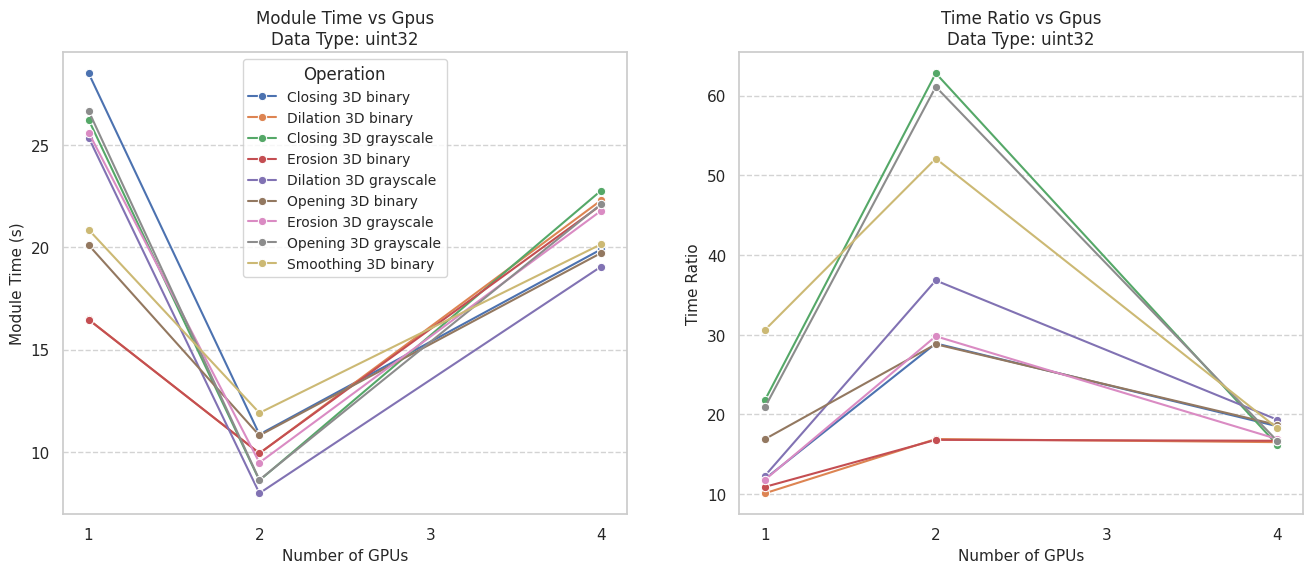

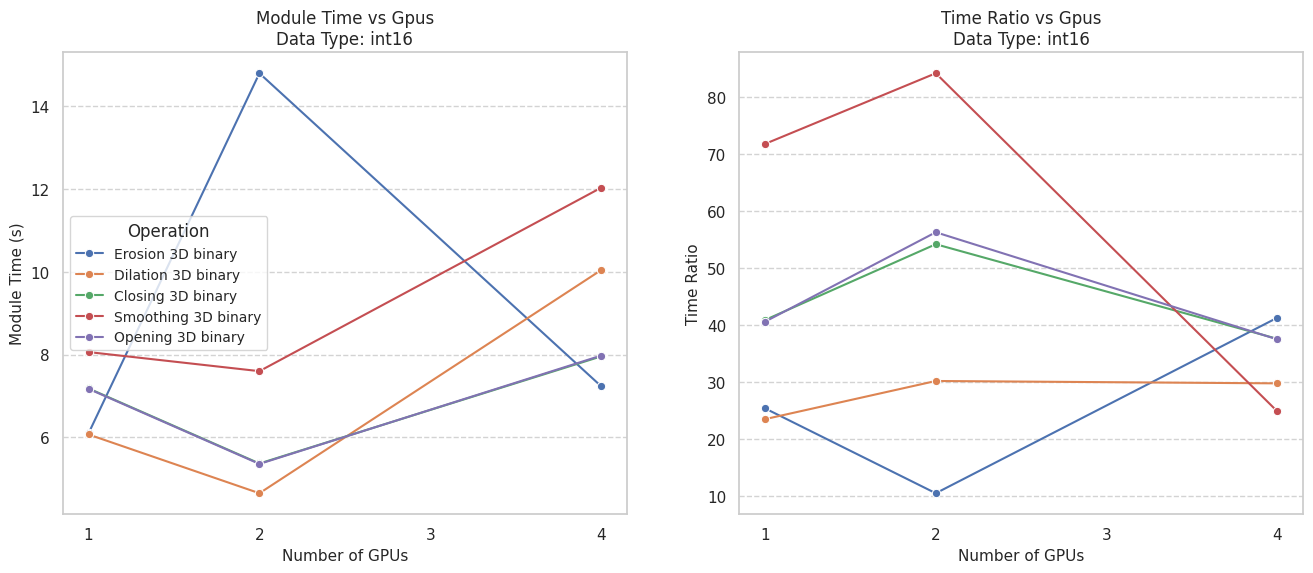

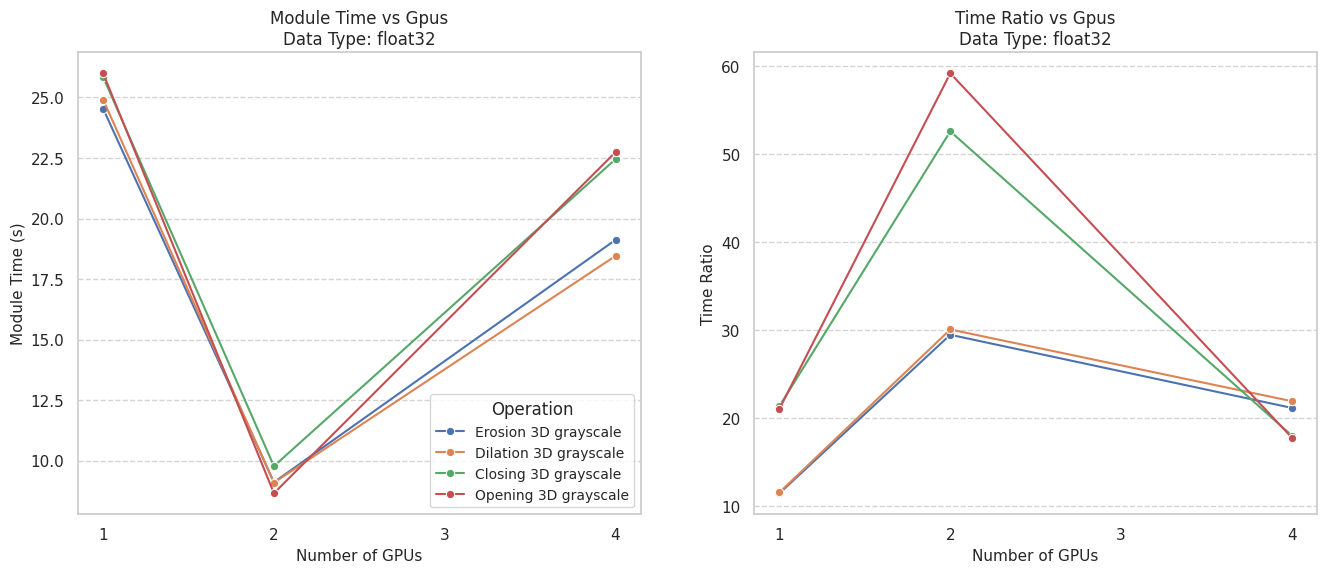

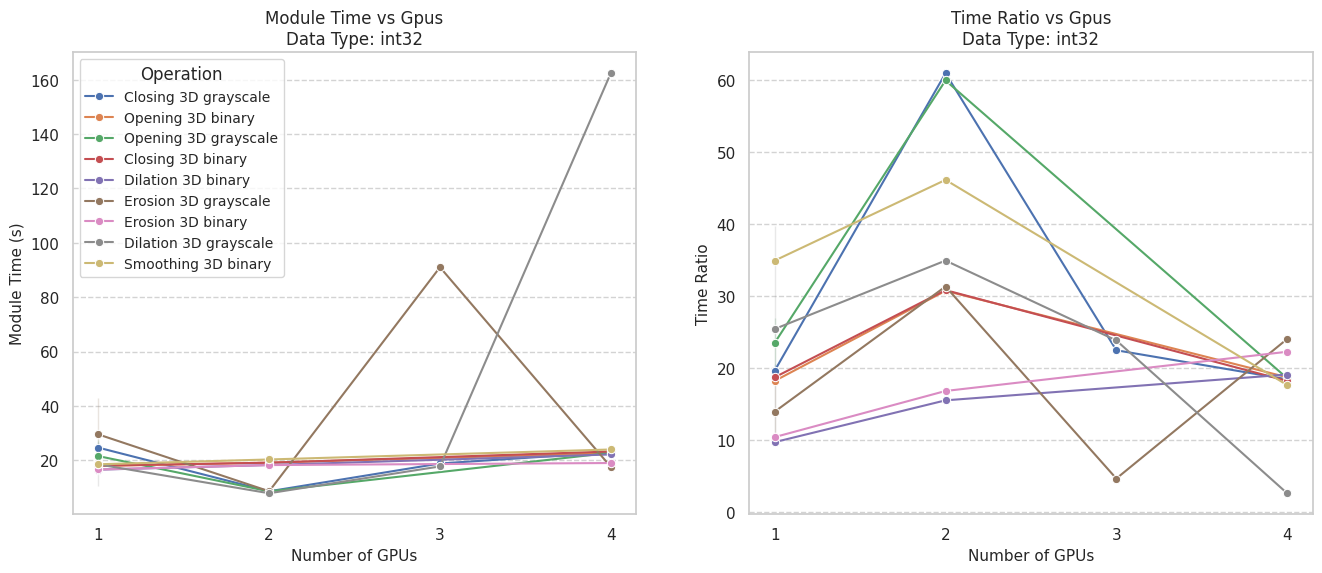

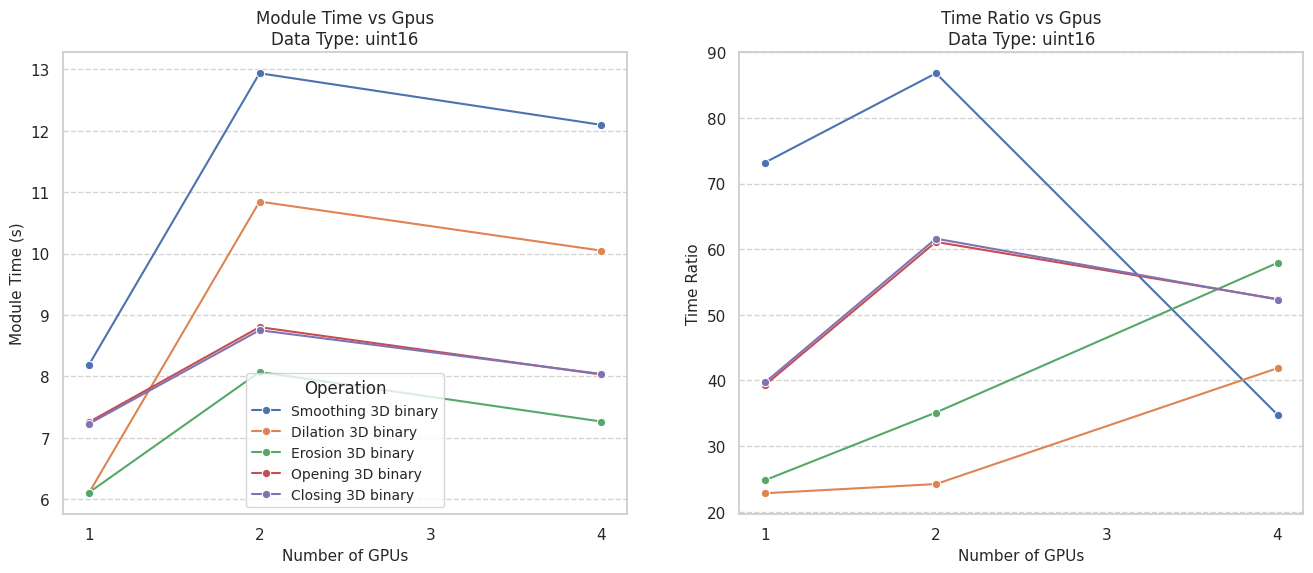

In [59]:
# Filter for huge images
df_huge = df[df['Image Dimensions'] == '(2052, 2052, 2048)']
# Get unique values of 'Image Dimensions' and 'Image Data Type'
image_dims = df_huge['Image Dimensions'].unique()
data_types = df_huge['Image Data Type'].unique()

# Get unique GPU values sorted
gpu_ticks = sorted(df_huge['Gpus'].unique())

# Define font size for ticks
FONT_SIZE = 11  

for img_dim in ['(2052, 2052, 2048)']:
    for dtype in data_types:
        subset = df_huge[(df_huge['Image Dimensions'] == img_dim) & (df_huge['Image Data Type'] == dtype)]
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))  # Side-by-side layout

        # First plot: Module Time vs GPUs
        sns.lineplot(data=subset, x='Gpus', y='Module Time (s)', hue='Operation', marker='o', ax=axes[0])
        axes[0].set_title(f"Module Time vs Gpus\nData Type: {dtype}", fontsize=FONT_SIZE+1)
        axes[0].set_xlabel("Number of GPUs", fontsize=FONT_SIZE)
        axes[0].set_ylabel("Module Time (s)", fontsize=FONT_SIZE)
        axes[0].legend(title="Operation", fontsize=FONT_SIZE - 1)
        axes[0].set_xticks(gpu_ticks)
    
        # Second plot: Time Ratio vs GPUs (without legend)
        sns.lineplot(data=subset, x='Gpus', y='Time Ratio', hue='Operation', marker='o', ax=axes[1])
        axes[1].set_title(f"Time Ratio vs Gpus\nData Type: {dtype}", fontsize=FONT_SIZE+1)
        axes[1].set_xlabel("Number of GPUs", fontsize=FONT_SIZE)
        axes[1].set_ylabel("Time Ratio", fontsize=FONT_SIZE)
        axes[1].set_xticks(gpu_ticks)
        axes[1].get_legend().remove()
        
        # Set font size for x and y ticks
        for ax in axes:
            ax.tick_params(axis='both', labelsize=FONT_SIZE)  # Increase font size
            ax.yaxis.grid(True)  # Keep only horizontal grid lines
            ax.xaxis.grid(False)  # Remove vertical grid lines

        # Save the figure
        filename = f"{output_dir}/benchmark_plot_{dtype.replace(' ', '_')}.png"
        if(save): plt.savefig(filename, dpi=300, bbox_inches='tight')  # High-quality save
        
plt.show()

## Cyhton test

In [60]:
save = True #wheter to save the plots as figures
notebook_name = "benchmark_read"
output_dir = f"{notebook_name}_plots"
os.makedirs(output_dir, exist_ok=True)
print(f"Plots will be saved to: {output_dir}")

Plots will be saved to: benchmark_read_plots


In [61]:
current_dir = os.getcwd()
df_cython = read_csv_files(current_dir+"/results_cython/")
df_cython = df_cython.dropna(axis=1, how='all')
df_cython

Searching in: /ibira/lnls/labs/tepui/home/camila.araujo/work/harpia/tests_python/benchmark/results_cython/
Loaded 2 CSV files.


,Operation,Machine,Gpus,gpuMemory,Module Time (s),Repetitions,Image Data Type,Image Size (MB),Image Dimensions
0,Erosion 3D grayscale,notebook,1,0.1,0.742144,20,int32,1739.5,"(600, 1520, 500)"
1,Erosion 3D grayscale,notebook,1,0.1,0.674391,20,int32,1739.5,"(600, 1520, 500)"
2,Dilation 3D grayscale,notebook,1,0.1,0.622666,20,int32,1739.5,"(600, 1520, 500)"
3,Closing 3D grayscale,notebook,1,0.1,0.795179,20,int32,1739.5,"(600, 1520, 500)"
4,Opening 3D grayscale,notebook,1,0.1,0.793879,20,int32,1739.5,"(600, 1520, 500)"
...,...,...,...,...,...,...,...,...,...
216,Erosion 3D binary,harriet,1,0.2,28.696902,1,int32,32896.1,"(2052, 2052, 2048)"
217,Dilation 3D binary,harriet,1,0.2,28.592246,1,int32,32896.1,"(2052, 2052, 2048)"
218,Closing 3D binary,harriet,1,0.2,19.462814,1,int32,32896.1,"(2052, 2052, 2048)"
219,Opening 3D binary,harriet,1,0.2,22.730940,1,int32,32896.1,"(2052, 2052, 2048)"


## Cuda test

### Read data

In [117]:
df_cuda['Machine'].unique()

array(['harriet', 'notebook'], dtype=object)

In [119]:
current_dir = os.getcwd()
cuda_results_dir = os.path.join(current_dir, "results_cuda")
df_cuda = read_csv_files(cuda_results_dir)
df_cuda

Searching in: /ibira/lnls/labs/tepui/home/camila.araujo/work/harpia/tests_python/benchmark/results_cuda
Loaded 9 CSV files.


,Operation,Machine,Gpus,gpuMemory,Module Time (s),Repetitions,Image Data Type,xsize,ysize,zsize
0,read_input,harriet,2,0.1,36498141,1,uint16->int32,2052,2052,2048
1,erosion_binary,harriet,2,0.1,9582751,10,int32,2052,2052,2048
2,dilation_binary,harriet,2,0.1,9954022,10,int32,2052,2052,2048
3,closing_binary,harriet,2,0.1,13426532,10,int32,2052,2052,2048
4,opening_binary,harriet,2,0.1,13587228,10,int32,2052,2052,2048
...,...,...,...,...,...,...,...,...,...,...
1274,opening_grayscale,harriet,3,0.4,8374596,20,int32,2052,2052,2048
1275,geodesic_erosion_grayscale,harriet,3,0.4,11857777,20,int32,2052,2052,2048
1276,geodesic_dilation_grayscale,harriet,3,0.4,11935538,20,int32,2052,2052,2048
1277,top_hat,harriet,3,0.4,8533452,20,int32,2052,2052,2048


In [120]:
save = True #wheter to save the plots as figures
notebook_name = "benchmark_read_20reps"
output_dir = f"{notebook_name}_plots"
os.makedirs(output_dir, exist_ok=True)
print(f"Plots will be saved to: {output_dir}")

Plots will be saved to: benchmark_read_20reps_plots


### Complete df information

In [121]:
#Correct time unit
df_cuda["Module Time (s)"] = df_cuda.apply(lambda row: row["Module Time (s)"]/(10e5), axis=1)

dtype_bytes = {
    'int16': 2, 'uint16': 2,
    'int32': 4, 'uint32': 4,
    'int64': 8, 'uint64': 8,
    'float32': 4
}

# Add the "Image Dimensions" column
df_cuda["Image Dimensions"] = df_cuda.apply(lambda row: f"({row['xsize']}, {row['ysize']}, {row['zsize']})", axis=1)

# Function to compute the image size in MB
def compute_image_size(row):
    shape = row['xsize'] * row['ysize'] * row['zsize']
    dtype_str = row['Image Data Type']
    bytes_per_pixel = dtype_bytes.get(dtype_str, 0)  # 0 if unknown type
    size_in_mb = shape * bytes_per_pixel / (1024 ** 2)
    return round(size_in_mb, 1)

# Add the "Image Size (MB)" column
df_cuda["Image Size (MB)"] = df_cuda.apply(compute_image_size, axis=1)

df_cuda = df_cuda[df_cuda['Operation'] != 'read_input']

In [122]:
#workaround to plot only for 20 repetitions ina new directory
df_cuda_notebook = df_cuda[df_cuda['Machine']=='notebook']
df_cuda = df_cuda[df_cuda['Repetitions']==20]
df_cuda

,Operation,Machine,Gpus,gpuMemory,Module Time (s),Repetitions,Image Data Type,xsize,ysize,zsize,Image Dimensions,Image Size (MB)
239,erosion_binary,harriet,2,0.1,11.306026,20,int32,2052,2052,2048,"(2052, 2052, 2048)",32896.1
240,dilation_binary,harriet,2,0.1,8.964166,20,int32,2052,2052,2048,"(2052, 2052, 2048)",32896.1
241,closing_binary,harriet,2,0.1,9.902074,20,int32,2052,2052,2048,"(2052, 2052, 2048)",32896.1
242,opening_binary,harriet,2,0.1,9.976260,20,int32,2052,2052,2048,"(2052, 2052, 2048)",32896.1
243,smooth_binary,harriet,2,0.1,11.288935,20,int32,2052,2052,2048,"(2052, 2052, 2048)",32896.1
...,...,...,...,...,...,...,...,...,...,...,...,...
1274,opening_grayscale,harriet,3,0.4,8.374596,20,int32,2052,2052,2048,"(2052, 2052, 2048)",32896.1
1275,geodesic_erosion_grayscale,harriet,3,0.4,11.857777,20,int32,2052,2052,2048,"(2052, 2052, 2048)",32896.1
1276,geodesic_dilation_grayscale,harriet,3,0.4,11.935538,20,int32,2052,2052,2048,"(2052, 2052, 2048)",32896.1
1277,top_hat,harriet,3,0.4,8.533452,20,int32,2052,2052,2048,"(2052, 2052, 2048)",32896.1


### Plots Harriet

#### Time vs Number of Gpus

/ibira/lnls/labs/tepui/home/camila.araujo/work/envs/jupyter/lib/python3.9/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  func(*plot_args, **plot_kwargs)
/ibira/lnls/labs/tepui/home/camila.araujo/work/envs/jupyter/lib/python3.9/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  func(*plot_args, **plot_kwargs)
/ibira/lnls/labs/tepui/home/camila.araujo/work/envs/jupyter/lib/python3.9/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  func(*plot_args, **plot_kwargs)
/ibira/lnls/labs/tepui/home/camila.araujo/work/envs/jupyter/lib/python3.9/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  func(*plot_args, **plot_kwargs)
/ibira/lnls/labs/tepui/home/camila.arauj

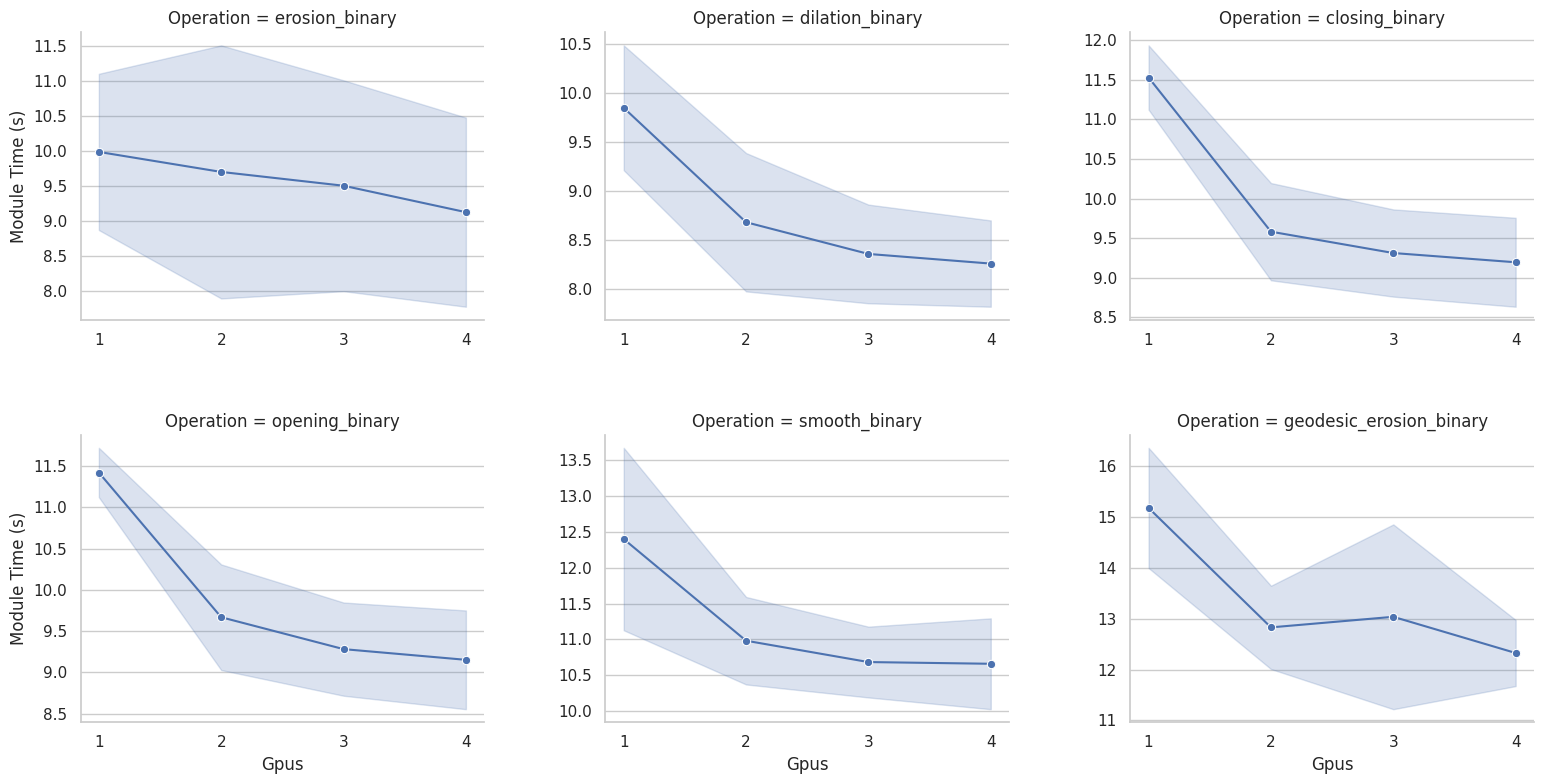

/ibira/lnls/labs/tepui/home/camila.araujo/work/envs/jupyter/lib/python3.9/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  func(*plot_args, **plot_kwargs)
/ibira/lnls/labs/tepui/home/camila.araujo/work/envs/jupyter/lib/python3.9/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  func(*plot_args, **plot_kwargs)
/ibira/lnls/labs/tepui/home/camila.araujo/work/envs/jupyter/lib/python3.9/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  func(*plot_args, **plot_kwargs)
/ibira/lnls/labs/tepui/home/camila.araujo/work/envs/jupyter/lib/python3.9/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  func(*plot_args, **plot_kwargs)
/ibira/lnls/labs/tepui/home/camila.arauj

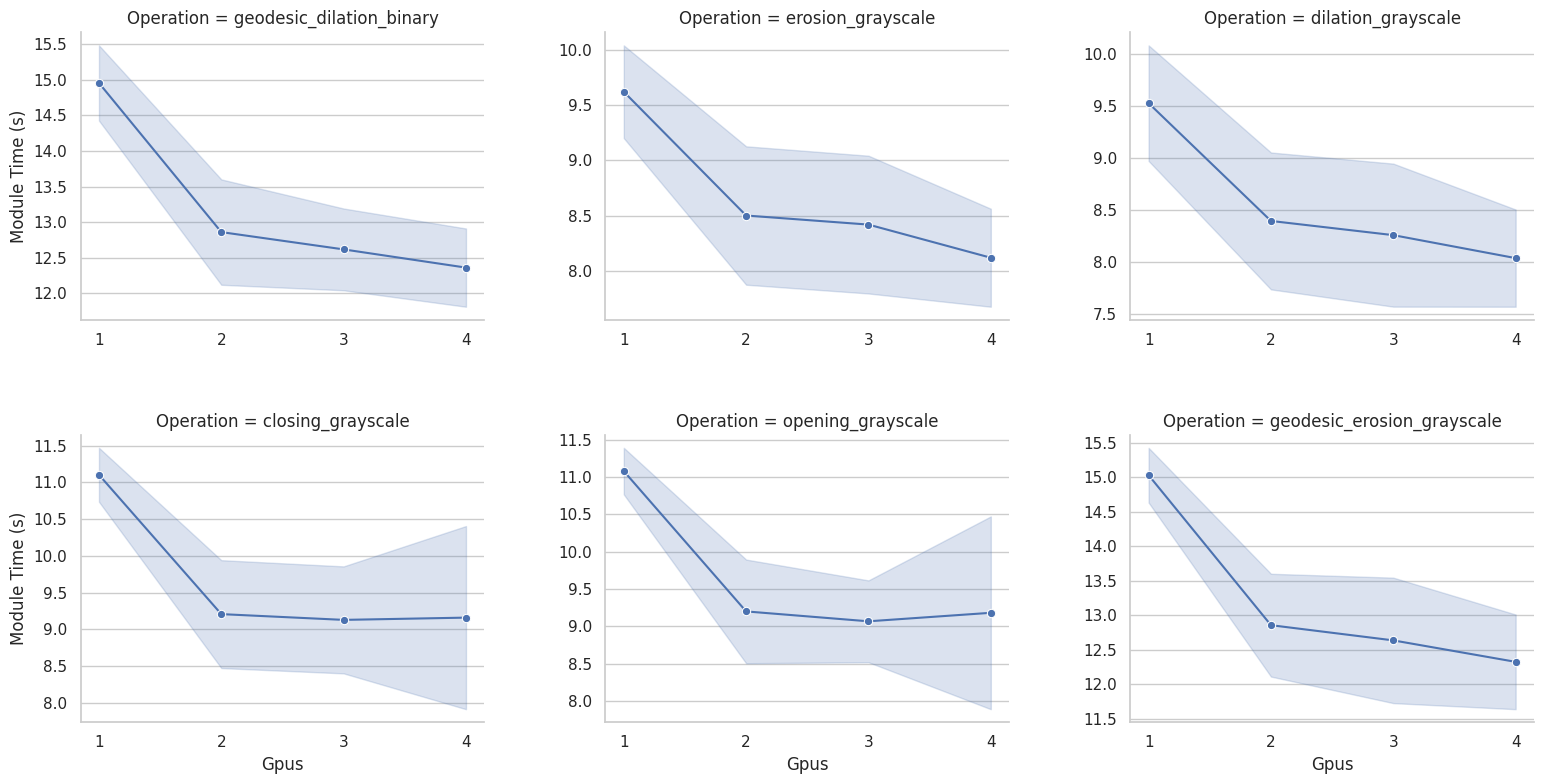

/ibira/lnls/labs/tepui/home/camila.araujo/work/envs/jupyter/lib/python3.9/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  func(*plot_args, **plot_kwargs)
/ibira/lnls/labs/tepui/home/camila.araujo/work/envs/jupyter/lib/python3.9/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  func(*plot_args, **plot_kwargs)
/ibira/lnls/labs/tepui/home/camila.araujo/work/envs/jupyter/lib/python3.9/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  func(*plot_args, **plot_kwargs)


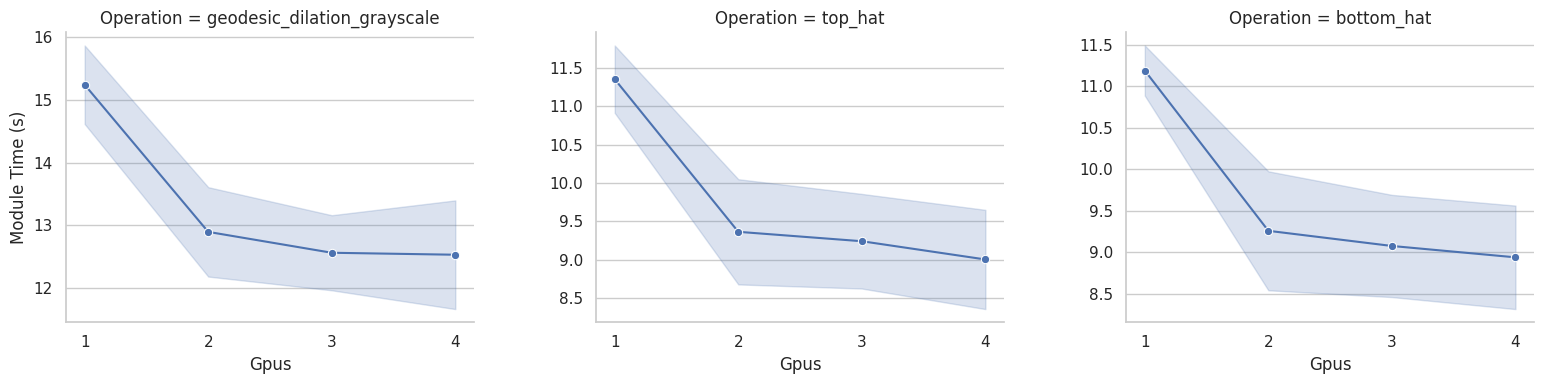

In [97]:
# Filter the dataset
df_filtered = df_cuda[df_cuda["Machine"] == "harriet"]

# Get unique Operations and Gpus
unique_ops = df_filtered["Operation"].unique()
unique_gpus = sorted(df_filtered["Gpus"].unique())

# Group Operations in chunks of 6
ops_per_plot = 6
n_chunks = int(np.ceil(len(unique_ops) / ops_per_plot))

sns.set(style="whitegrid")

for i in range(n_chunks):
    ops_chunk = unique_ops[i * ops_per_plot:(i + 1) * ops_per_plot]
    chunk_df = df_filtered[df_filtered["Operation"].isin(ops_chunk)]

    g = sns.relplot(
        data=chunk_df,
        x="Gpus",
        y="Module Time (s)",
        col="Operation",
        col_wrap=3,  # Always 3 columns
        kind="line",
        ci="sd",
        marker="o",
        facet_kws={'sharey': False, 'sharex': True},
        height=4,
        aspect=1.3
    )

    # Force xticks and labels to appear in every subplot
    for ax in g.axes.flat:
        ax.set_xticks(unique_gpus)
        ax.tick_params(axis='x', labelbottom=True)

    plt.tight_layout()
    plt.subplots_adjust(hspace=0.4, wspace=0.3)
    plt.show()

/tmp/ipykernel_2952044/543199289.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  ax = sns.lineplot(


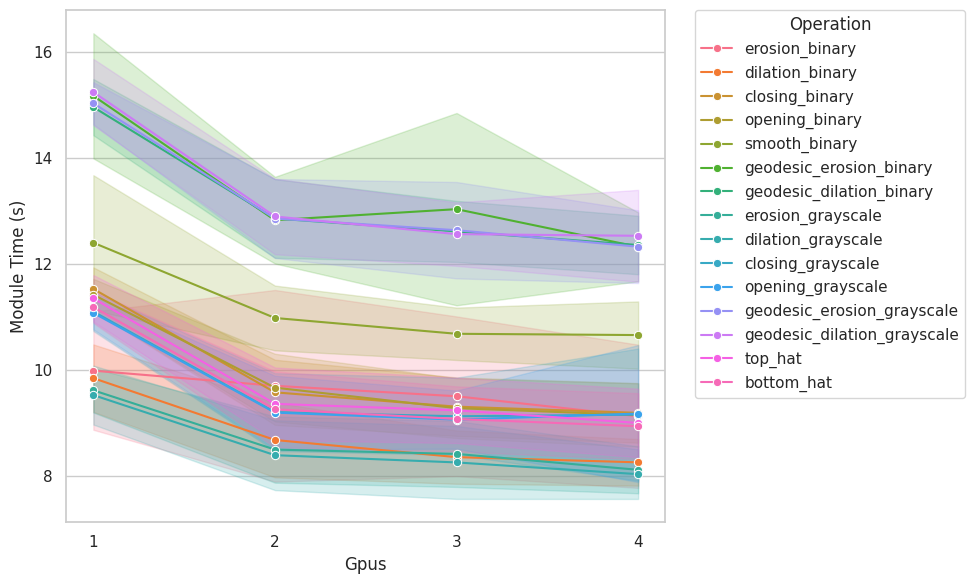

In [98]:
# Filter data
df_filtered = df_cuda[df_cuda["Machine"] == "harriet"]

# Create the plot
plt.figure(figsize=(10, 6))
ax = sns.lineplot(
    data=df_filtered,
    x="Gpus",
    y="Module Time (s)",
    hue="Operation",
    ci="sd",
    marker="o"
)

# Move legend outside
ax.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    borderaxespad=0.,
    title="Operation"
)

# Set xticks to the unique Gpus
ax.set_xticks(sorted(df_filtered["Gpus"].unique()))

plt.tight_layout()
plt.show()

#### Time vs Number of Gpus (Trends)

In [99]:
df_cuda

,Operation,Machine,Gpus,gpuMemory,Module Time (s),Repetitions,Image Data Type,xsize,ysize,zsize,Image Dimensions,Image Size (MB)
239,erosion_binary,harriet,2,0.1,11.306026,20,int32,2052,2052,2048,"(2052, 2052, 2048)",32896.1
240,dilation_binary,harriet,2,0.1,8.964166,20,int32,2052,2052,2048,"(2052, 2052, 2048)",32896.1
241,closing_binary,harriet,2,0.1,9.902074,20,int32,2052,2052,2048,"(2052, 2052, 2048)",32896.1
242,opening_binary,harriet,2,0.1,9.976260,20,int32,2052,2052,2048,"(2052, 2052, 2048)",32896.1
243,smooth_binary,harriet,2,0.1,11.288935,20,int32,2052,2052,2048,"(2052, 2052, 2048)",32896.1
...,...,...,...,...,...,...,...,...,...,...,...,...
1274,opening_grayscale,harriet,3,0.4,8.374596,20,int32,2052,2052,2048,"(2052, 2052, 2048)",32896.1
1275,geodesic_erosion_grayscale,harriet,3,0.4,11.857777,20,int32,2052,2052,2048,"(2052, 2052, 2048)",32896.1
1276,geodesic_dilation_grayscale,harriet,3,0.4,11.935538,20,int32,2052,2052,2048,"(2052, 2052, 2048)",32896.1
1277,top_hat,harriet,3,0.4,8.533452,20,int32,2052,2052,2048,"(2052, 2052, 2048)",32896.1


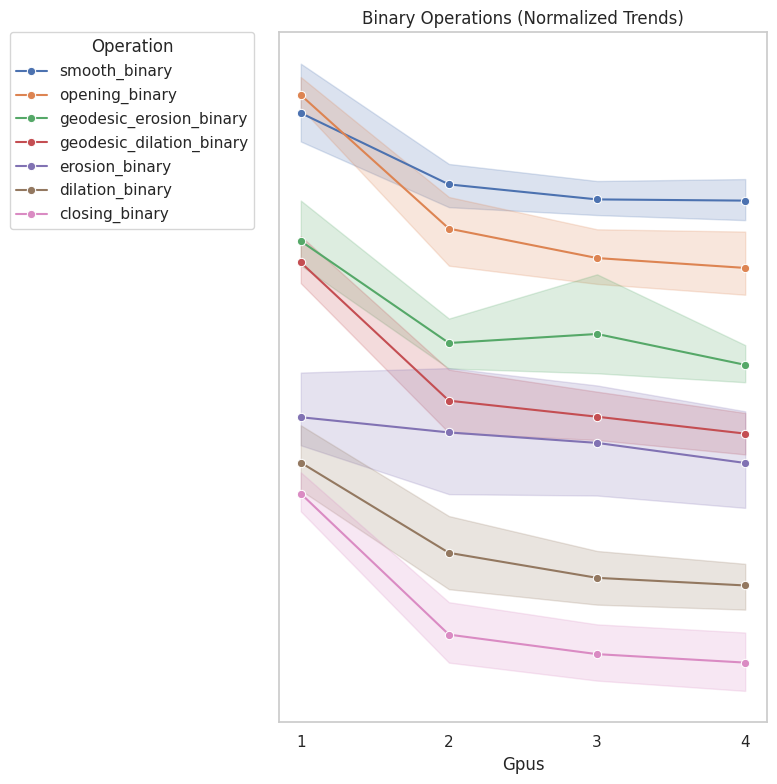

In [100]:
# Binary operation list
binary_ops = [
    'erosion_binary', 'dilation_binary', 'closing_binary',
    'opening_binary', 'smooth_binary', 'geodesic_erosion_binary',
    'geodesic_dilation_binary'
]
binary_ops.sort(reverse=True)

# Filter and prepare data
df_binary = df_cuda[(df_cuda["Machine"] == "harriet") & (df_cuda["Operation"].isin(binary_ops))].copy()

# Normalize and offset
offset_step = 0.3
operation_offsets = {op: i * offset_step for i, op in enumerate(sorted(df_binary["Operation"].unique()))}

df_normalized = []
for op, group in df_binary.groupby("Operation"):
    offset = operation_offsets[op]
    norm_time = (group["Module Time (s)"] - group["Module Time (s)"].min()) / (
        group["Module Time (s)"].max() - group["Module Time (s)"].min()
    )
    group = group.copy()
    group["Offset Time"] = norm_time + offset
    df_normalized.append(group)

df_plot_binary = pd.concat(df_normalized)

# Plot
plt.figure(figsize=(8, 8))
ax = sns.lineplot(
    data=df_plot_binary,
    x="Gpus",
    y="Offset Time",
    hue="Operation",
    hue_order = binary_ops,
    marker="o"
)
ax.legend(bbox_to_anchor=(-0.05, 1), loc='upper right', borderaxespad=0., title="Operation")
ax.set_xticks(sorted(df_binary["Gpus"].unique()))
ax.set_yticks([])
ax.set_ylabel("")
plt.title("Binary Operations (Normalized Trends)")
plt.tight_layout()
plt.show()

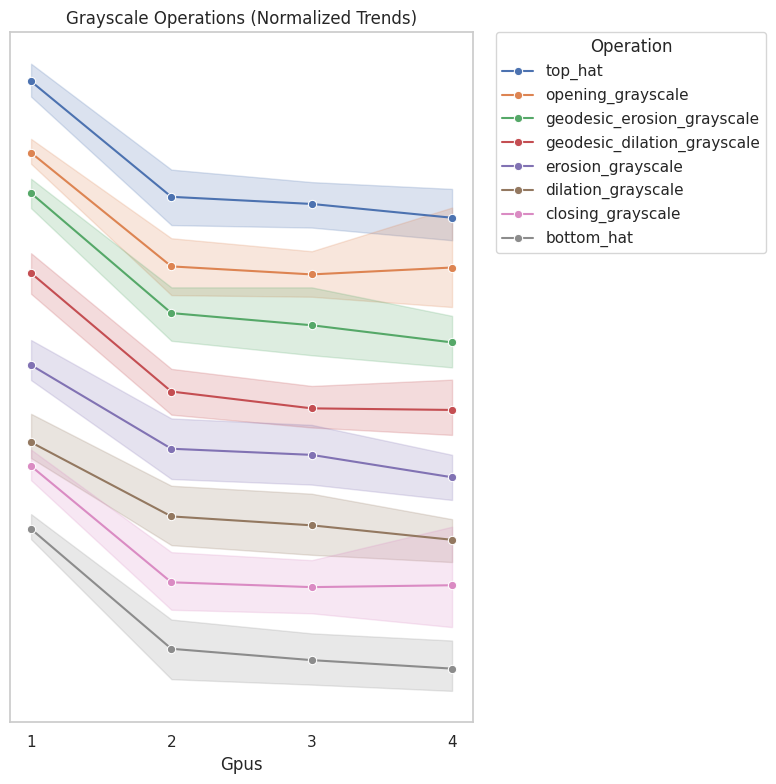

In [101]:
# Grayscale operation list
grayscale_ops = [
    'erosion_grayscale', 'dilation_grayscale', 'closing_grayscale',
    'opening_grayscale', 'geodesic_erosion_grayscale', 'geodesic_dilation_grayscale',
    'top_hat', 'bottom_hat'
]
grayscale_ops.sort(reverse=True)
# Filter and prepare data
df_grayscale = df_cuda[(df_cuda["Machine"] == "harriet") & (df_cuda["Operation"].isin(grayscale_ops))].copy()

# Normalize and offset
operation_offsets = {op: i * offset_step for i, op in enumerate(sorted(df_grayscale["Operation"].unique()))}

df_normalized = []
for op, group in df_grayscale.groupby("Operation"):
    offset = operation_offsets[op]
    norm_time = (group["Module Time (s)"] - group["Module Time (s)"].min()) / (
        group["Module Time (s)"].max() - group["Module Time (s)"].min()
    )
    group = group.copy()
    group["Offset Time"] = norm_time + offset
    df_normalized.append(group)

df_plot_grayscale = pd.concat(df_normalized)

# Plot
plt.figure(figsize=(8, 8))
ax = sns.lineplot(
    data=df_plot_grayscale,
    x="Gpus",
    y="Offset Time",
    hue="Operation",
    hue_order = grayscale_ops,
    marker="o"
)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., title="Operation")
ax.set_xticks(sorted(df_grayscale["Gpus"].unique()))
ax.set_yticks([])
ax.set_ylabel("")
plt.title("Grayscale Operations (Normalized Trends)")
plt.tight_layout()
plt.show()


#### Time vs Numper of Gpus (for each gpuMemory individually)

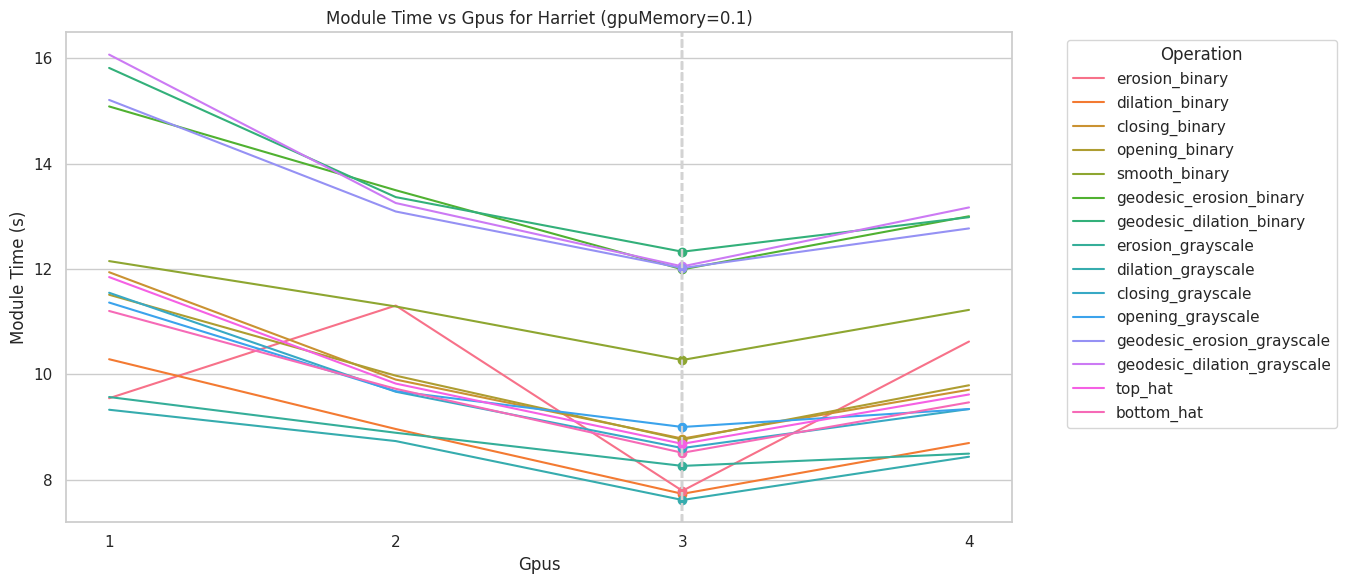

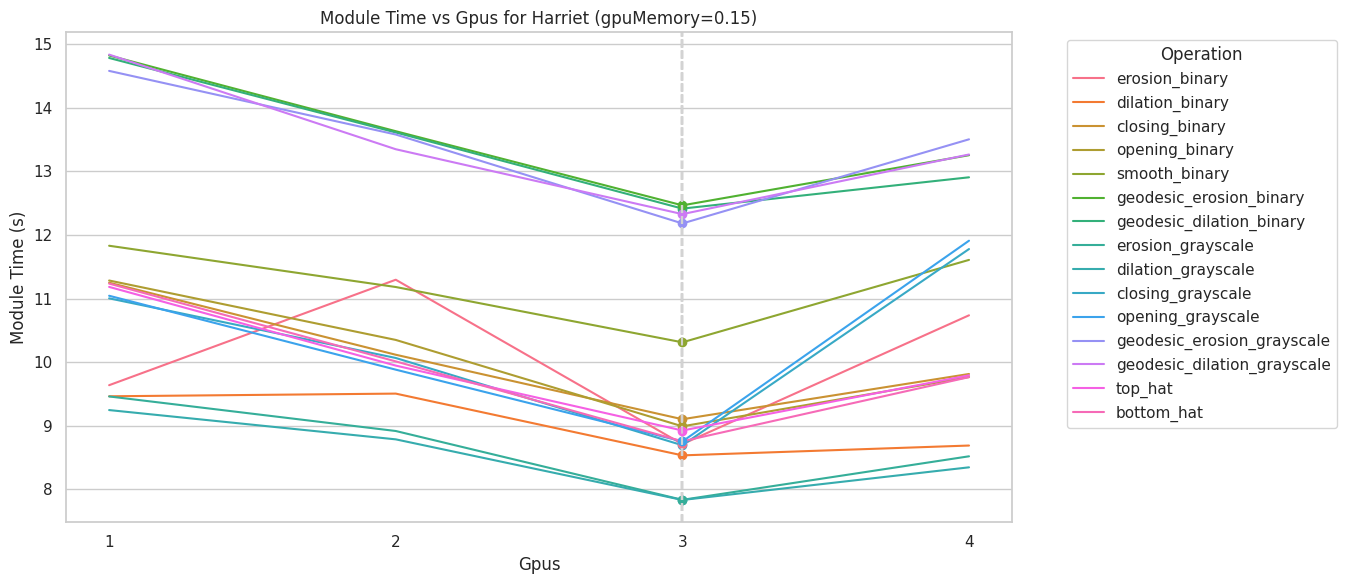

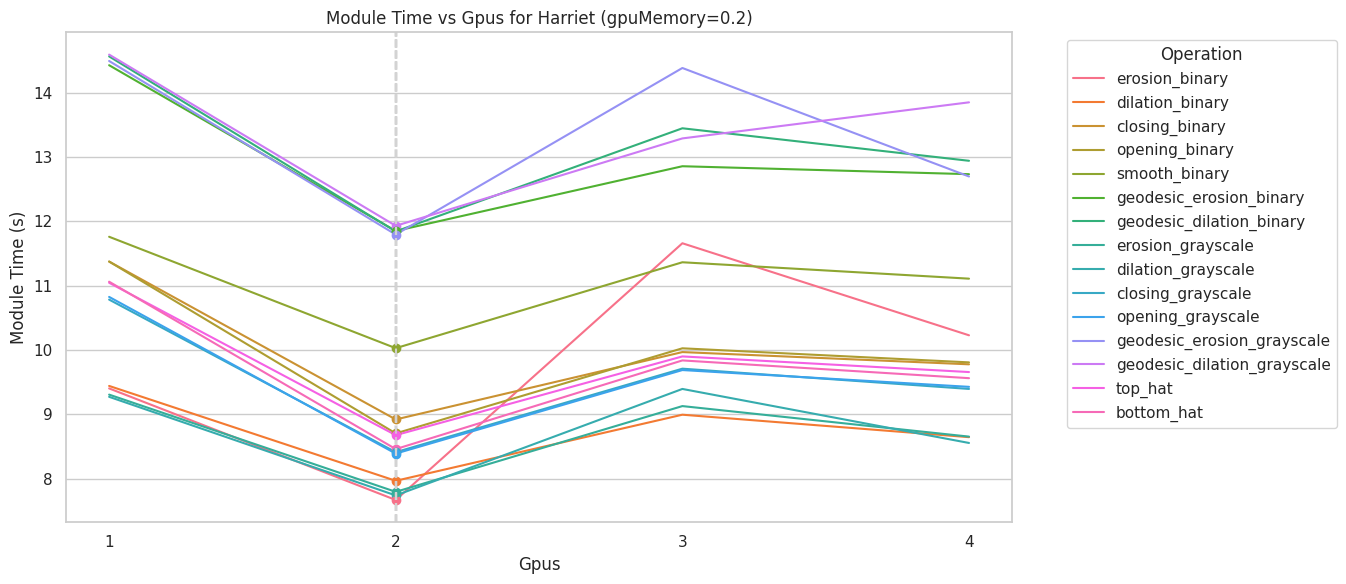

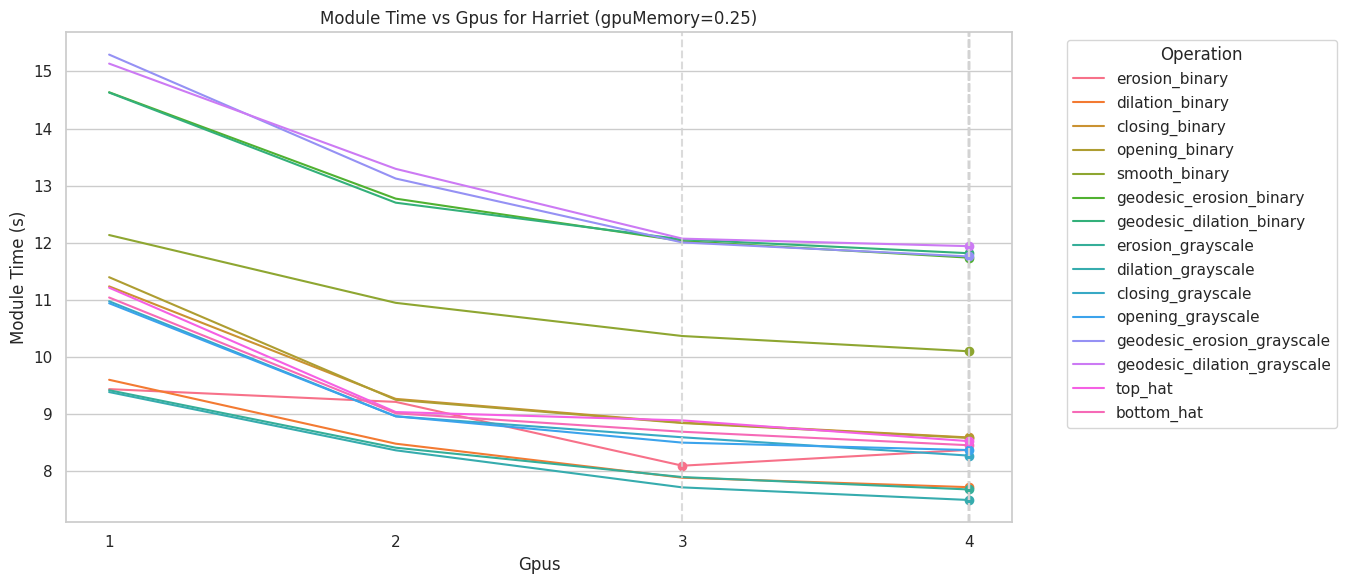

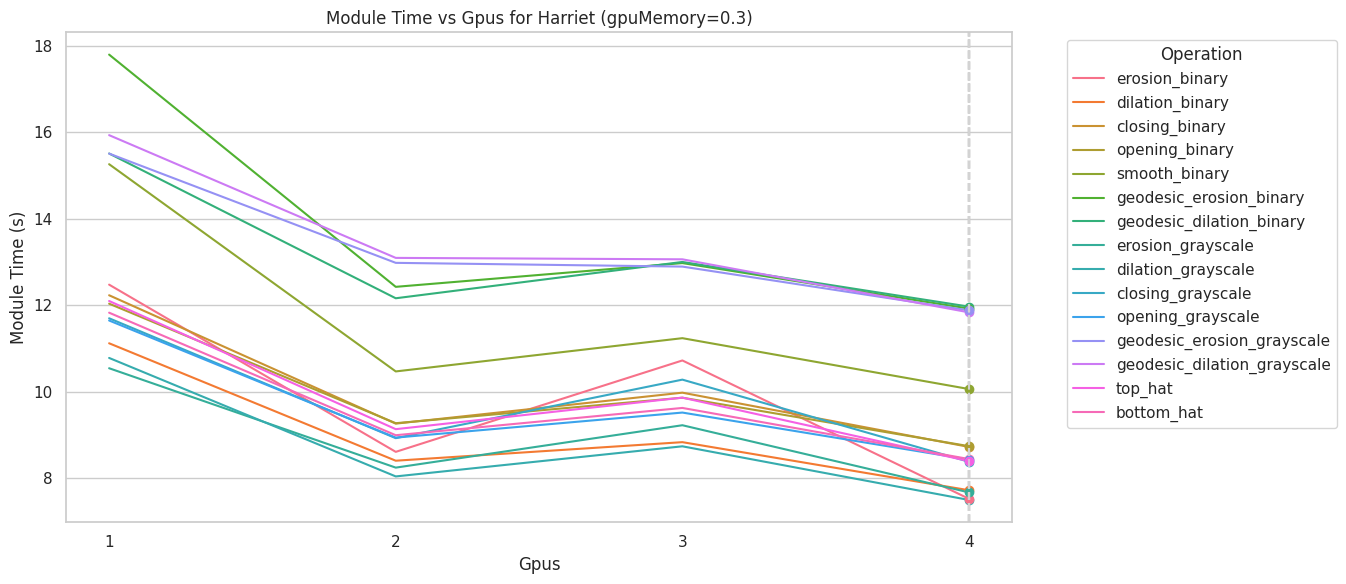

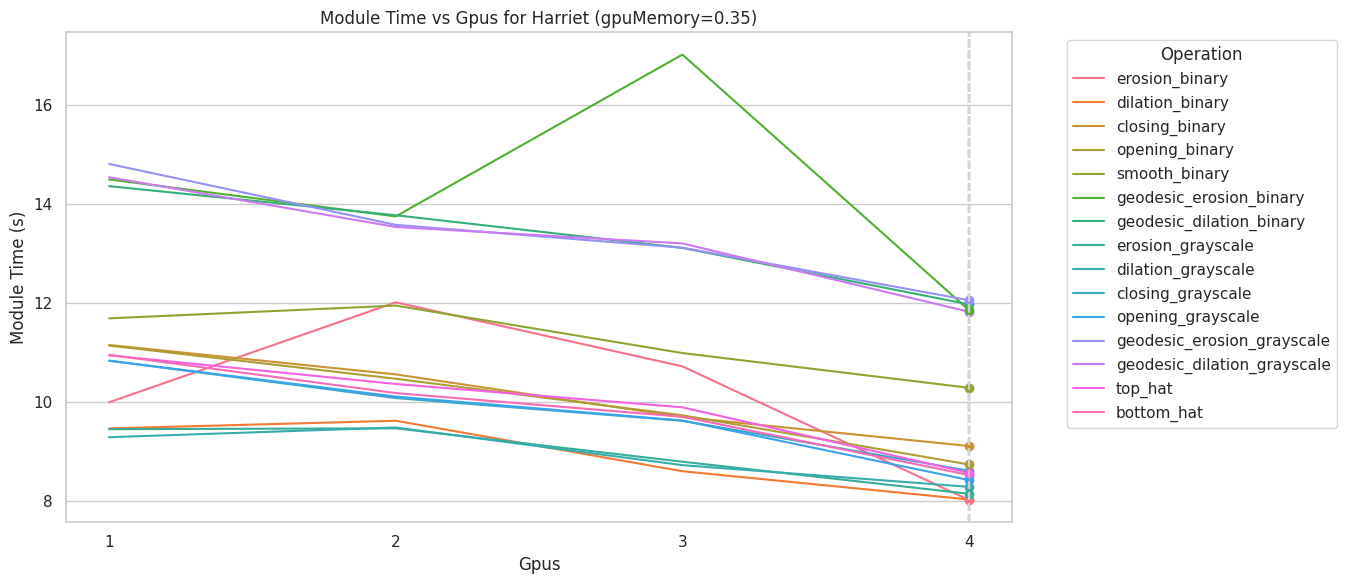

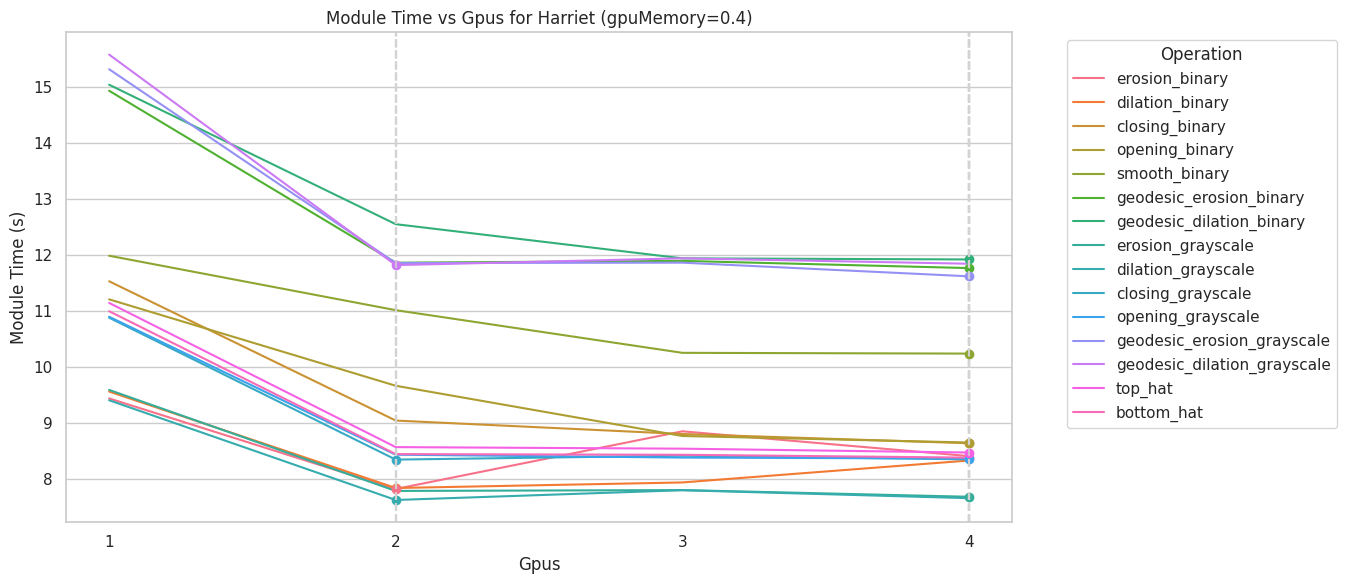

In [102]:
# Set style for horizontal grid only
sns.set_style("whitegrid")
plt.rcParams["axes.grid"] = True
plt.rcParams["axes.grid.axis"] = "y"
plt.rcParams["axes.grid.which"] = "major"

all_gpu_mems = sorted(df_cuda["gpuMemory"].unique())

for gpu_mem in all_gpu_mems:
    df_filtered_1 = df_cuda[df_cuda["gpuMemory"] == gpu_mem]
    df_filtered = df_filtered_1[df_filtered_1["Machine"] == "harriet"]
    
    if df_filtered.empty:
        continue  # Skip if no data

    fig, ax = plt.subplots(figsize=(12, 6))
    
    lineplot = sns.lineplot(
        data=df_filtered,
        x="Gpus",
        y="Module Time (s)",
        hue="Operation",
        ax=ax
    )
    
    # Get line colors by operation
    line_colors = {line.get_label(): line.get_color() for line in ax.get_lines()}

    # Plot dots and vertical dashed lines for min points
    for operation, group in df_filtered.groupby("Operation"):
        group_sorted = group.sort_values("Gpus")
        min_row = group_sorted.loc[group_sorted["Module Time (s)"].idxmin()]
        x_val = min_row["Gpus"]
        y_val = min_row["Module Time (s)"]
        color = line_colors[operation]
        ax.plot(x_val, y_val, "o", color=color)
        ax.axvline(x=x_val, linestyle="--", color="lightgray", alpha=0.8)

    # Title and labels
    ax.set_title(f"Module Time vs Gpus for Harriet (gpuMemory={gpu_mem})")
    ax.set_xlabel("Gpus")
    ax.set_ylabel("Module Time (s)")
    ax.set_xticks(sorted(df_filtered["Gpus"].unique()))

    # Custom legend
    handles, labels = ax.get_legend_handles_labels()
    unique_ops = df_filtered["Operation"].unique().tolist()
    new_handles_labels = [
        (h, l) for h, l in zip(handles, labels)
        if l in unique_ops
    ]
    if new_handles_labels:
        handles, labels = zip(*new_handles_labels)
        ax.legend(handles, labels, title="Operation", loc='upper left', bbox_to_anchor=(1.05, 1))

    plt.tight_layout()
    plt.subplots_adjust(right=0.85)
    if(save): plt.savefig(f"{output_dir}/harriet_gpuMemory{gpu_mem}_gpus.png", dpi=300, bbox_inches='tight')
    plt.show()


#### Time vs gpuMemory (for each Numper of Gpus individually)

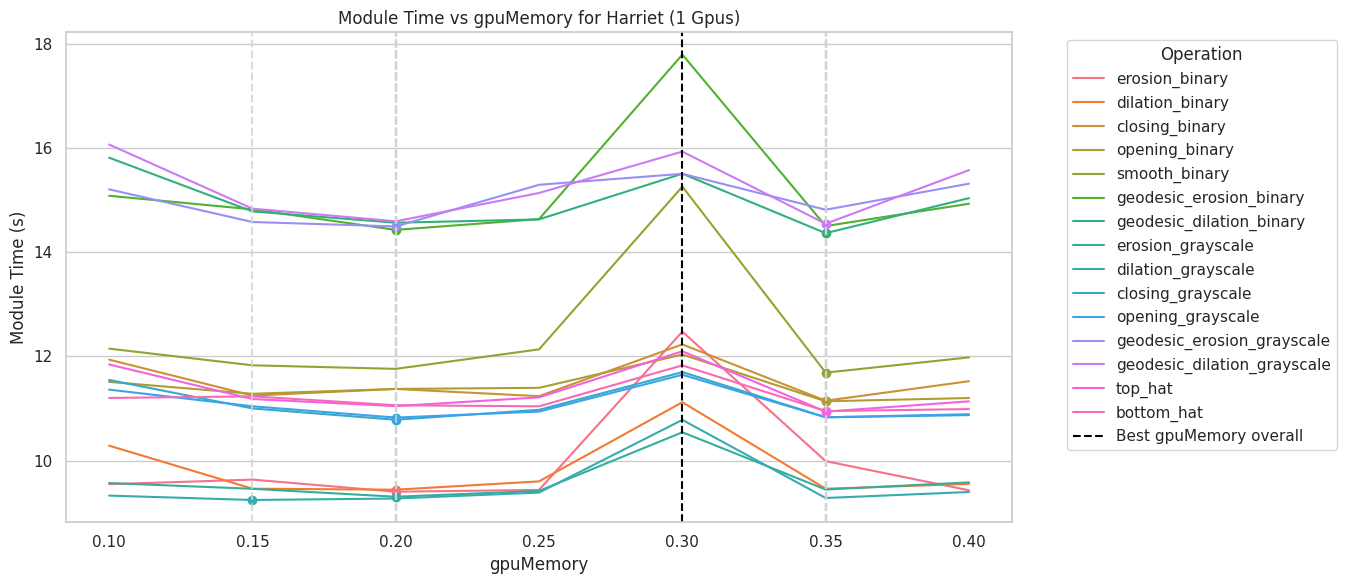

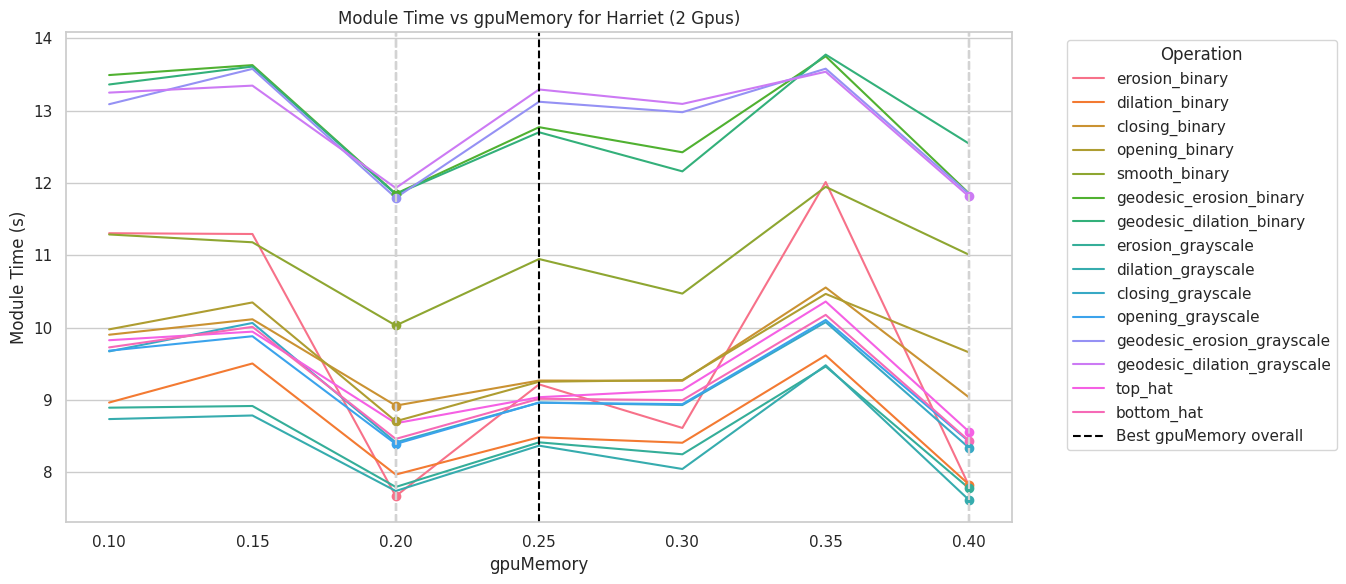

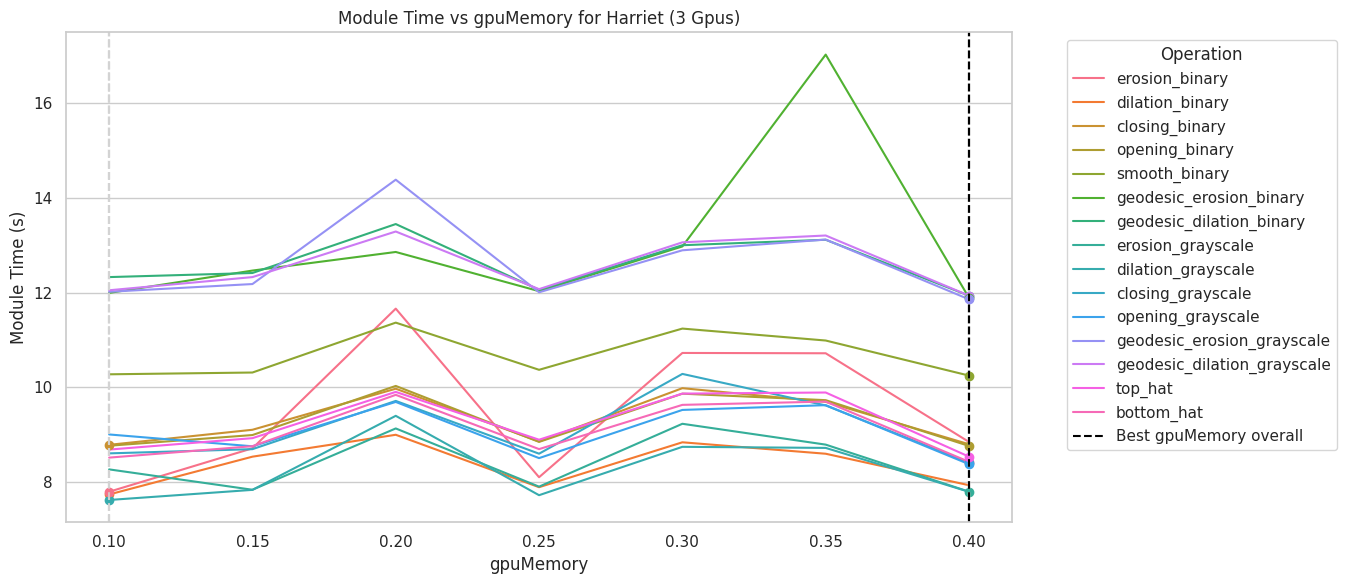

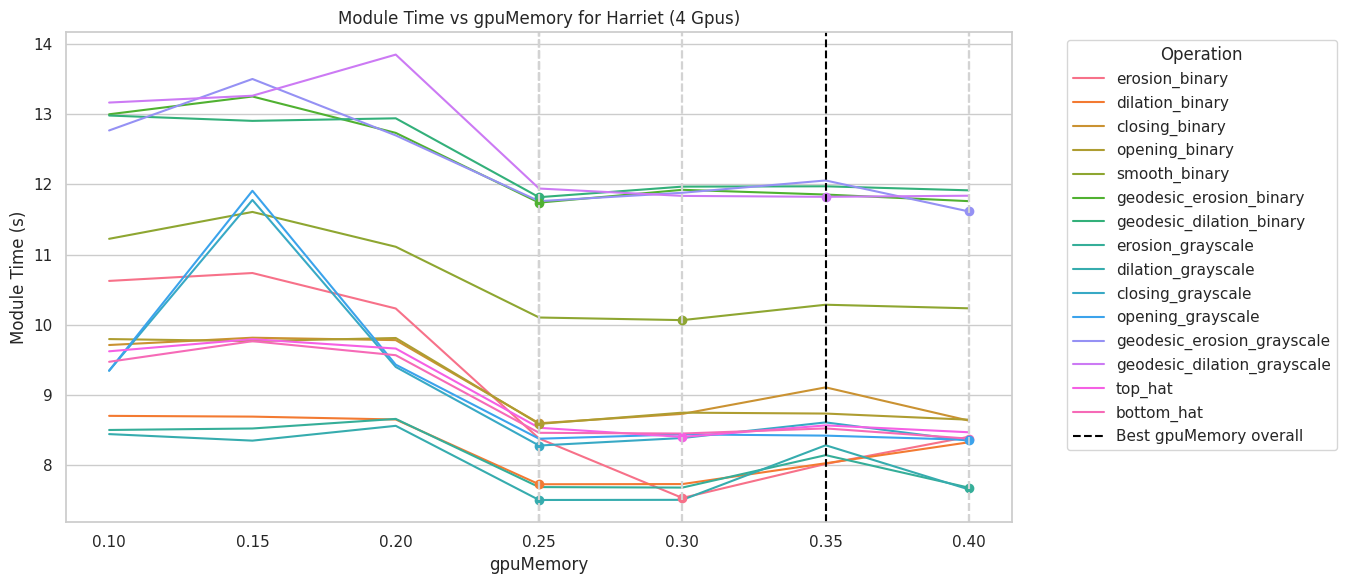

In [103]:
# Dictionary of gpu count to new line position
new_lines = {1: 0.3, 2: 0.25, 3: 0.4, 4: 0.35}
all_gpus = sorted(new_lines.keys())

# Set style for horizontal grid only
sns.set_style("whitegrid")
plt.rcParams["axes.grid"] = True
plt.rcParams["axes.grid.axis"] = "y"
plt.rcParams["axes.grid.which"] = "major"

for ngpus in all_gpus:
    df_filtered_1 = df_cuda[df_cuda["Gpus"] == ngpus]
    df_filtered = df_filtered_1[df_filtered_1["Machine"] == "harriet"]
    
    if df_filtered.empty:
        continue  # Skip if no data
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    lineplot = sns.lineplot(
        data=df_filtered,
        x="gpuMemory",
        y="Module Time (s)",
        hue="Operation",
        ax=ax
    )
    
    # Get line colors by operation
    line_colors = {line.get_label(): line.get_color() for line in ax.get_lines()}
    
    # Plot dots and vertical dashed lines for min points
    for operation, group in df_filtered.groupby("Operation"):
        group_sorted = group.sort_values("gpuMemory")
        min_row = group_sorted.loc[group_sorted["Module Time (s)"].idxmin()]
        x_val = min_row["gpuMemory"]
        y_val = min_row["Module Time (s)"]
        color = line_colors[operation]
        ax.plot(x_val, y_val, "o", color=color)
        ax.axvline(x=x_val, linestyle="--", color="lightgray", alpha=0.8)

    # Determine monotonic decreasing cutoff
    valid_gpu_mems = sorted(df_filtered["gpuMemory"].unique())
    decreasing_cutoff = None
    for i in range(len(valid_gpu_mems)):
        current_cutoff = valid_gpu_mems[i]
        is_decreasing = True
        for operation, group in df_filtered.groupby("Operation"):
            sub = group.sort_values("gpuMemory")
            sub = sub[sub["gpuMemory"] <= current_cutoff]
            if not all(np.diff(sub["Module Time (s)"]) < 0):
                is_decreasing = False
                break
        if is_decreasing:
            decreasing_cutoff = current_cutoff

    # Add the specific black vertical line for this GPU count
    ax.axvline(
        x=new_lines[ngpus],
        linestyle="--",
        color="black",
        label="Best gpuMemory overall"
    )

    # Title and labels
    ax.set_title(f"Module Time vs gpuMemory for Harriet ({ngpus} Gpus)")
    ax.set_xlabel("gpuMemory")
    ax.set_ylabel("Module Time (s)")
    ax.set_xticks(valid_gpu_mems)

    # Custom legend
    handles, labels = ax.get_legend_handles_labels()
    unique_ops = df_filtered["Operation"].unique().tolist()
    new_handles_labels = [
        (h, l) for h, l in zip(handles, labels)
        if l in unique_ops or l in {"Best gpuMemory overall"}
    ]
    if new_handles_labels:
        handles, labels = zip(*new_handles_labels)
        ax.legend(handles, labels, title="Operation", loc='upper left', bbox_to_anchor=(1.05, 1))

    plt.tight_layout()
    plt.subplots_adjust(right=0.85)
    if(save): plt.savefig(f"{output_dir}/harriet_{ngpus}gpus_gpuMemory.png", dpi=300, bbox_inches='tight')
    plt.show()


In [104]:
# Filter the data
ngpus = 2
df_gpus = df_cuda[df_cuda["Gpus"] == ngpus]
df_filtered = df_gpus[df_gpus["Machine"] == "harriet"]

# Set the monotonic threshold value
threshold_gpu_mem = 0.2

# Prepare list to collect data
summary_data = []

# Process each operation
for operation, group in df_filtered.groupby("Operation"):
    group_sorted = group.sort_values("gpuMemory")

    # Get the min Module Time and corresponding gpuMemory
    min_row = group_sorted.loc[group_sorted["Module Time (s)"].idxmin()]
    min_time = min_row["Module Time (s)"]
    min_mem = min_row["gpuMemory"]

    # Get the Module Time at the threshold 
    thresh_row = group_sorted[group_sorted["gpuMemory"] == threshold_gpu_mem]
    if thresh_row.empty:
        continue  # Skip if the threshold is not available
    thresh_time = thresh_row["Module Time (s)"].values[0]

    # Compute absolute and relative differences
    abs_diff_us = (thresh_time - min_time) * 1e3  # Convert to miliseconds
    perc_faster = 100 * (1 - min_time / thresh_time)

    # Append to list
    summary_data.append({
        "Operation": operation,
        "Min Time (s)": min_time,
        "Min gpuMemory": min_mem,
        "Time - 0.2 gpuMemory (s)": thresh_time,
        "Saved Time (ms)": abs_diff_us,
        "Faster (%)": perc_faster
    })

# Create DataFrame
summary_df = pd.DataFrame(summary_data)

# Round for display
summary_df["Saved Time (ms)"] = summary_df["Saved Time (ms)"].round(2)
summary_df["Faster (%)"] = summary_df["Faster (%)"].round(2)

# Display the table
summary_df = summary_df.sort_values("Faster (%)", ascending=False)
display(summary_df)

,Operation,Min Time (s),Min gpuMemory,Time - 0.2 gpuMemory (s),Saved Time (ms),Faster (%)
3,dilation_binary,7.830361,0.4,7.968001,137.64,1.73
4,dilation_grayscale,7.616414,0.4,7.740798,124.38,1.61
14,top_hat,8.561238,0.4,8.677812,116.57,1.34
8,geodesic_dilation_grayscale,11.814150,0.4,11.931884,117.73,0.99
2,closing_grayscale,8.337968,0.4,8.413375,75.41,0.90
0,bottom_hat,8.436066,0.4,8.460975,24.91,0.29
6,erosion_grayscale,7.778034,0.4,7.796469,18.44,0.24
1,closing_binary,8.921771,0.2,8.921771,0.00,0.00
5,erosion_binary,7.669998,0.2,7.669998,0.00,0.00
7,geodesic_dilation_binary,11.844683,0.2,11.844683,0.00,0.00


In [105]:
# Get all unique gpuMemory values
gpu_mem_values = sorted(df_filtered["gpuMemory"].unique())

# Prepare the new summary list
summary_data = []

# Process each operation
for operation, group in df_filtered.groupby("Operation"):
    group_sorted = group.sort_values("gpuMemory")

    # Find the minimum time and corresponding memory
    min_row = group_sorted.loc[group_sorted["Module Time (s)"].idxmin()]
    min_time = min_row["Module Time (s)"]
    min_mem = min_row["gpuMemory"]

    # Start with base row
    row = {
        "Operation": operation,
        "Min Time (s)": min_time,
        "Min gpuMemory": min_mem
    }

    # Add Faster (%) columns for each gpuMemory
    for mem in gpu_mem_values:
        mem_row = group_sorted[group_sorted["gpuMemory"] == mem]
        if mem_row.empty:
            row[f"Fast (%) @ {mem}"] = None
        else:
            time = mem_row["Module Time (s)"].values[0]
            row[f"Fast (%) @ {mem}"] = round(100 * (1 - time / min_time), 2)

    summary_data.append(row)

# Create DataFrame
summary_df = pd.DataFrame(summary_data)

# Identify the best gpuMemory: the one with the highest average "Fast (%)" (i.e., closest to 0 or above)
gpu_speed_cols = [col for col in summary_df.columns if col.startswith("Fast (%) @")]
avg_speed_by_mem = summary_df[gpu_speed_cols].mean(numeric_only=True).sort_values(ascending=False)

best_gpu_memory = avg_speed_by_mem.idxmax().replace("Fast (%) @ ", "")
best_speed_gain = avg_speed_by_mem.max()

# Display summary
display(summary_df.sort_values("Operation"))
print(f"\n✅ Best overall gpuMemory setting: {best_gpu_memory} (Avg gain: {best_speed_gain:.2f}%)")

,Operation,Min Time (s),Min gpuMemory,Fast (%) @ 0.1,Fast (%) @ 0.15,Fast (%) @ 0.2,Fast (%) @ 0.25,Fast (%) @ 0.3,Fast (%) @ 0.35,Fast (%) @ 0.4
0,bottom_hat,8.436066,0.4,-15.30,-18.67,-0.30,-6.88,-6.65,-20.63,0.00
1,closing_binary,8.921771,0.2,-10.99,-13.38,0.00,-3.88,-3.85,-18.31,-1.28
2,closing_grayscale,8.337968,0.4,-15.99,-20.71,-0.90,-7.50,-7.09,-20.85,0.00
3,dilation_binary,7.830361,0.4,-14.48,-21.38,-1.76,-8.35,-7.38,-22.81,0.00
4,dilation_grayscale,7.616414,0.4,-14.69,-15.35,-1.63,-9.87,-5.63,-24.46,0.00
5,erosion_binary,7.669998,0.2,-47.41,-47.27,0.00,-20.15,-12.29,-56.64,-1.86
6,erosion_grayscale,7.778034,0.4,-14.34,-14.64,-0.24,-8.17,-6.05,-21.67,0.00
7,geodesic_dilation_binary,11.844683,0.2,-12.82,-14.92,0.00,-7.24,-2.68,-16.31,-5.92
8,geodesic_dilation_grayscale,11.814150,0.4,-12.16,-12.98,-1.00,-12.53,-10.84,-14.61,0.00
9,geodesic_erosion_binary,11.851978,0.2,-13.85,-15.01,0.00,-7.77,-4.84,-16.04,-0.04



✅ Best overall gpuMemory setting: 0.2 (Avg gain: -0.48%)


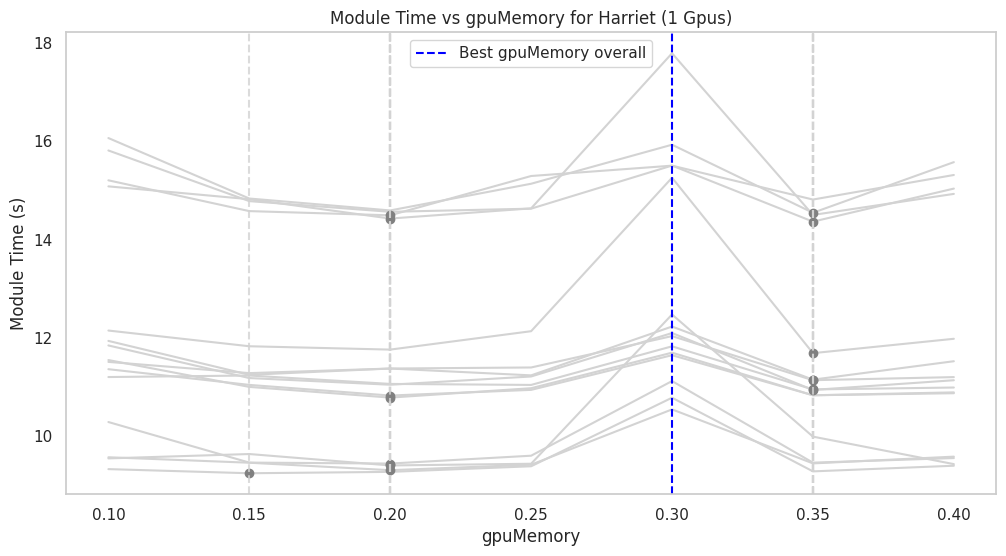

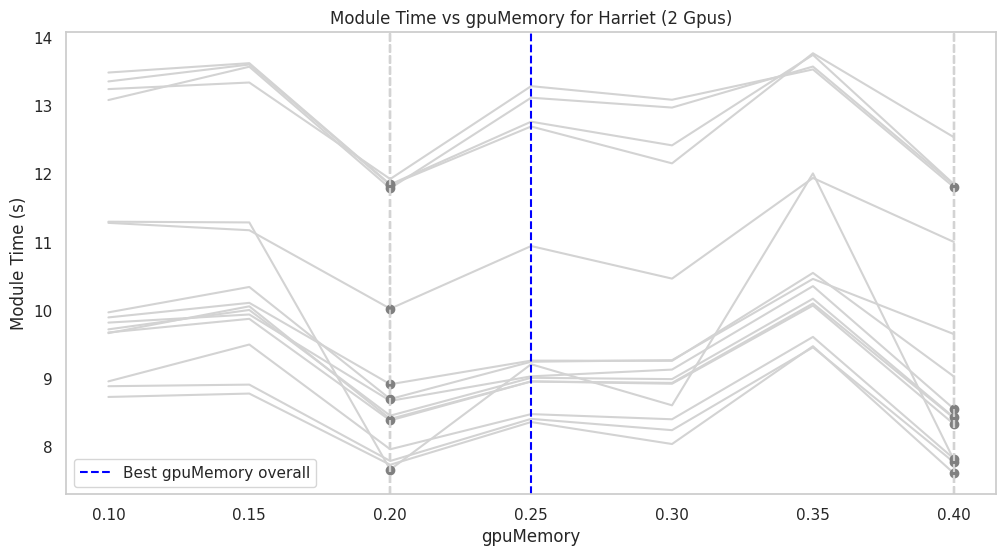

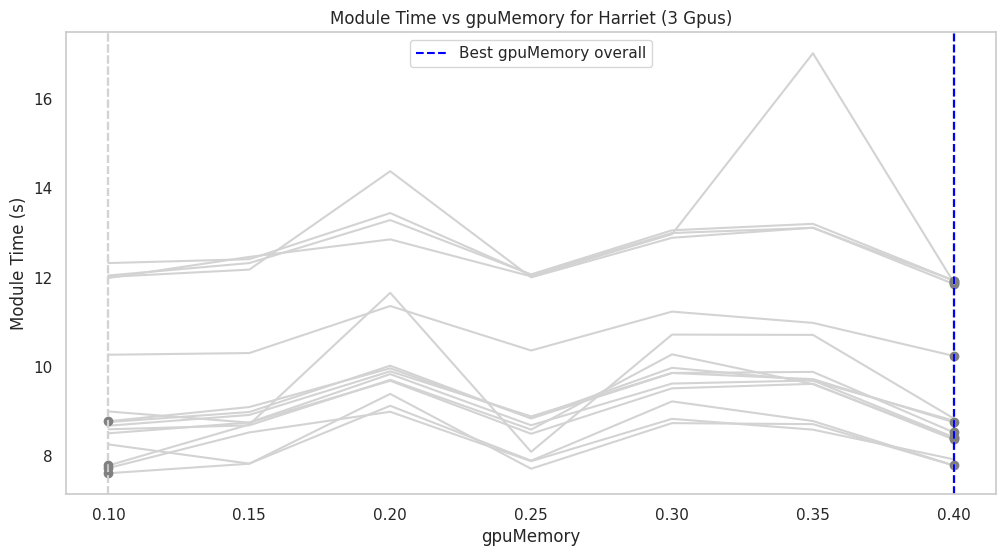

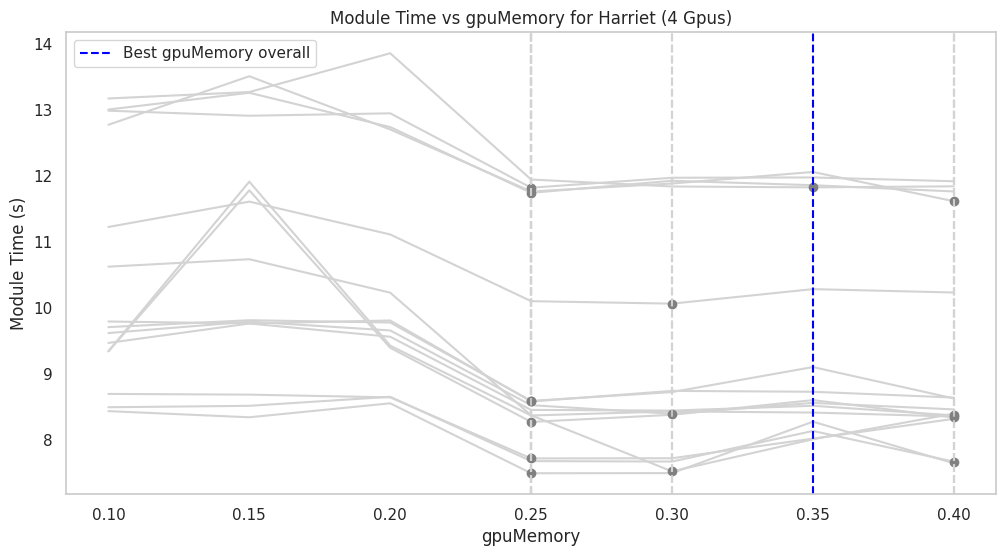

In [106]:
# Dictionary of gpu count to new line position
new_lines = {1: 0.3, 2: 0.25, 3: 0.4, 4: 0.35}
all_gpus = sorted(new_lines.keys())

# Set style for horizontal grid only
sns.set_style("whitegrid")
plt.rcParams["axes.grid"] = False
plt.rcParams["axes.grid.axis"] = "y"
plt.rcParams["grid.linestyle"] = "--"
plt.rcParams["grid.color"] = "lightgray"

for ngpus in all_gpus:
    df_filtered_1 = df_cuda[df_cuda["Gpus"] == ngpus]
    df_filtered = df_filtered_1[df_filtered_1["Machine"] == "harriet"]
    
    if df_filtered.empty:
        continue  # Skip if no data
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    lineplot = sns.lineplot(
        data=df_filtered,
        x="gpuMemory",
        y="Module Time (s)",
        hue="Operation",
    palette={op: "lightgray" for op in df_filtered["Operation"].unique()},
        ax=ax
    )
    
    # Get line colors by operation
    line_colors = {line.get_label(): line.get_color() for line in ax.get_lines()}
    
    # Plot dots and vertical dashed lines for min points
    for operation, group in df_filtered.groupby("Operation"):
        group_sorted = group.sort_values("gpuMemory")
        min_row = group_sorted.loc[group_sorted["Module Time (s)"].idxmin()]
        x_val = min_row["gpuMemory"]
        y_val = min_row["Module Time (s)"]
        color = line_colors[operation]
        ax.plot(x_val, y_val, "o", color="gray")
        ax.axvline(x=x_val, linestyle="--", color="lightgray", alpha=0.8)

    # Determine monotonic decreasing cutoff
    valid_gpu_mems = sorted(df_filtered["gpuMemory"].unique())
    decreasing_cutoff = None
    for i in range(len(valid_gpu_mems)):
        current_cutoff = valid_gpu_mems[i]
        is_decreasing = True
        for operation, group in df_filtered.groupby("Operation"):
            sub = group.sort_values("gpuMemory")
            sub = sub[sub["gpuMemory"] <= current_cutoff]
            if not all(np.diff(sub["Module Time (s)"]) < 0):
                is_decreasing = False
                break
        if is_decreasing:
            decreasing_cutoff = current_cutoff

    # Add the specific black vertical line for this GPU count
    ax.axvline(
        x=new_lines[ngpus],
        linestyle="--",
        color="blue",
        label="Best gpuMemory overall"
    )

    # Title and labels
    ax.set_title(f"Module Time vs gpuMemory for Harriet ({ngpus} Gpus)")
    ax.set_xlabel("gpuMemory")
    ax.set_ylabel("Module Time (s)")
    ax.set_xticks(valid_gpu_mems)
    
    # Custom legend: keep only dashed lines (i.e., threshold lines)
    handles, labels = ax.get_legend_handles_labels()
    keep_labels = {"Best gpuMemory overall"}
    new_handles_labels = [
        (h, l) for h, l in zip(handles, labels) if l in keep_labels
    ]
    if new_handles_labels:
        handles, labels = zip(*new_handles_labels)
        ax.legend(
            handles,
            labels,
            title="",
            loc='best',  # Let matplotlib decide the best position
            frameon=True
        )
    if(save): plt.savefig(f"{output_dir}/harriet_{ngpus}gpus_gpuMemory_trends.png", dpi=300, bbox_inches='tight')


### Plots Notebook

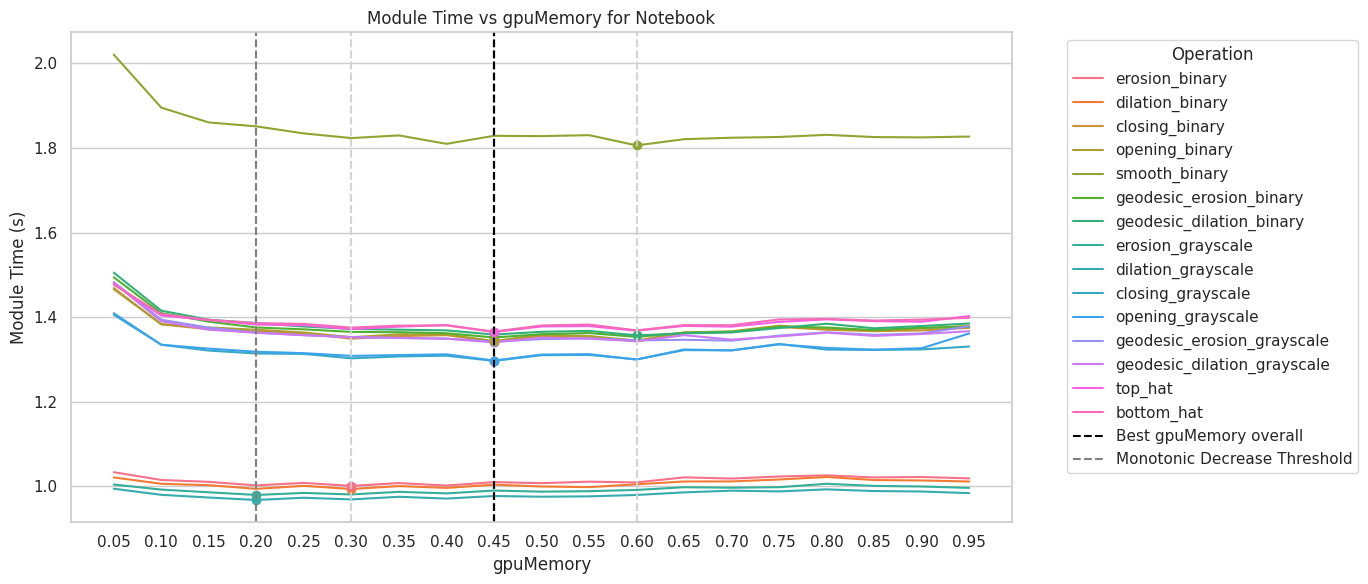

In [123]:
# Filter the data
df_filtered = df_cuda_notebook

# Set style for horizontal grid only
sns.set_style("whitegrid")
plt.rcParams["axes.grid"] = True
plt.rcParams["axes.grid.axis"] = "y"
plt.rcParams["axes.grid.which"] = "major"

# Create the plot
fig, ax = plt.subplots(figsize=(12, 6))

# Plot the main lines (no markers)
lineplot = sns.lineplot(
    data=df_filtered,
    x="gpuMemory",
    y="Module Time (s)",
    hue="Operation",
    ax=ax
)

# Get line colors by operation
line_colors = {line.get_label(): line.get_color() for line in ax.get_lines()}

# Add a dot and a vertical dashed line at the min point for each operation
for operation, group in df_filtered.groupby("Operation"):
    group_sorted = group.sort_values("gpuMemory")
    min_row = group_sorted.loc[group_sorted["Module Time (s)"].idxmin()]
    x_val = min_row["gpuMemory"]
    y_val = min_row["Module Time (s)"]
    color = line_colors[operation]

    # Plot the dot in the same color as the line
    ax.plot(x_val, y_val, "o", color=color)

    # Add a vertical dashed line in light gray
    ax.axvline(x=x_val, linestyle="--", color="lightgray", alpha=0.8)

# 🔍 Determine the largest gpuMemory value where all operations decrease up to that point
valid_gpu_mems = sorted(df_filtered["gpuMemory"].unique())
decreasing_cutoff = None

for i in range(len(valid_gpu_mems)):
    current_cutoff = valid_gpu_mems[i]
    is_decreasing = True
    for operation, group in df_filtered.groupby("Operation"):
        sub = group.sort_values("gpuMemory")
        sub = sub[sub["gpuMemory"] <= current_cutoff]
        if not all(np.diff(sub["Module Time (s)"]) < 0):
            is_decreasing = False
            break
    if is_decreasing:
        decreasing_cutoff = current_cutoff

# Add the specific black vertical line for this GPU count
ax.axvline(
    x=0.45,
    linestyle="--",
    color="black",
    label="Best gpuMemory overall"
)

# 🔲 Add black dashed line if found
if decreasing_cutoff is not None:
    black_line = ax.axvline(
        x=decreasing_cutoff,
        linestyle="--",
        color="gray",
        label="Monotonic Decrease Threshold"
    )

# Title and labels
ax.set_title('Module Time vs gpuMemory for Notebook')
ax.set_xlabel("gpuMemory")
ax.set_ylabel("Module Time (s)")
ax.set_xticks(valid_gpu_mems)

# 🎯 Custom legend with operations and threshold line
handles, labels = ax.get_legend_handles_labels()
unique_ops = df_filtered["Operation"].unique().tolist()
new_handles_labels = [
    (h, l) for h, l in zip(handles, labels)
    if l in unique_ops or l in {"Monotonic Decrease Threshold", "Best gpuMemory overall"}
]
if new_handles_labels:
    handles, labels = zip(*new_handles_labels)
    ax.legend(handles, labels, title="Operation", loc='upper left', bbox_to_anchor=(1.05, 1))

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(right=0.85)
if(save): plt.savefig(f"{output_dir}/notebook_gpuMemory.png", dpi=300, bbox_inches='tight')
plt.show()

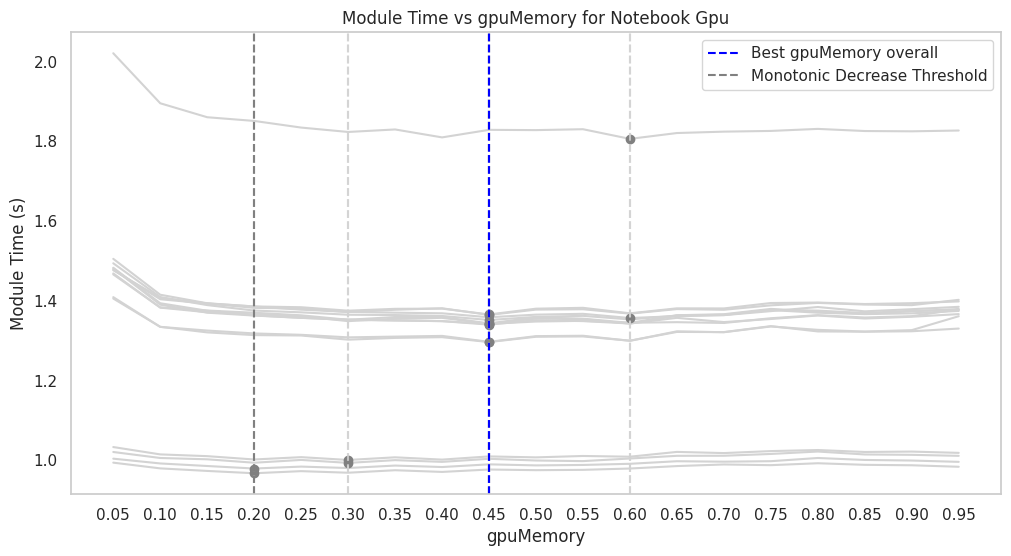

In [124]:
# Set style for horizontal grid only
sns.set_style("whitegrid")
plt.rcParams["axes.grid"] = False
plt.rcParams["axes.grid.axis"] = "y"
plt.rcParams["grid.linestyle"] = "--"
plt.rcParams["grid.color"] = "lightgray"

df_filtered = df_cuda_notebook

fig, ax = plt.subplots(figsize=(12, 6))

lineplot = sns.lineplot(
    data=df_filtered,
    x="gpuMemory",
    y="Module Time (s)",
    hue="Operation",
palette={op: "lightgray" for op in df_filtered["Operation"].unique()},
    ax=ax
)

# Get line colors by operation
line_colors = {line.get_label(): line.get_color() for line in ax.get_lines()}

# Plot dots and vertical dashed lines for min points
for operation, group in df_filtered.groupby("Operation"):
    group_sorted = group.sort_values("gpuMemory")
    min_row = group_sorted.loc[group_sorted["Module Time (s)"].idxmin()]
    x_val = min_row["gpuMemory"]
    y_val = min_row["Module Time (s)"]
    color = line_colors[operation]
    ax.plot(x_val, y_val, "o", color="gray")
    ax.axvline(x=x_val, linestyle="--", color="lightgray", alpha=0.8)

# Determine monotonic decreasing cutoff
valid_gpu_mems = sorted(df_filtered["gpuMemory"].unique())
decreasing_cutoff = None
for i in range(len(valid_gpu_mems)):
    current_cutoff = valid_gpu_mems[i]
    is_decreasing = True
    for operation, group in df_filtered.groupby("Operation"):
        sub = group.sort_values("gpuMemory")
        sub = sub[sub["gpuMemory"] <= current_cutoff]
        if not all(np.diff(sub["Module Time (s)"]) < 0):
            is_decreasing = False
            break
    if is_decreasing:
        decreasing_cutoff = current_cutoff

# Add the specific black vertical line for this GPU count
ax.axvline(
    x=0.45,
    linestyle="--",
    color="blue",
    label="Best gpuMemory overall"
)

# 🔲 Add black dashed line if found
if decreasing_cutoff is not None:
    black_line = ax.axvline(
        x=decreasing_cutoff,
        linestyle="--",
        color="gray",
        label="Monotonic Decrease Threshold"
    )

# Title and labels
ax.set_title(f"Module Time vs gpuMemory for Notebook Gpu")
ax.set_xlabel("gpuMemory")
ax.set_ylabel("Module Time (s)")
ax.set_xticks(valid_gpu_mems)

# Custom legend: keep only dashed lines (i.e., threshold lines)
handles, labels = ax.get_legend_handles_labels()
keep_labels = {"Monotonic Decrease Threshold", "Best gpuMemory overall"}
new_handles_labels = [
    (h, l) for h, l in zip(handles, labels) if l in keep_labels
]
if new_handles_labels:
    handles, labels = zip(*new_handles_labels)
    ax.legend(
        handles,
        labels,
        title="",
        loc='best',  # Let matplotlib decide the best position
        frameon=True
    )
if(save): plt.savefig(f"{output_dir}/notebook_gpuMemory_trends.png", dpi=300, bbox_inches='tight')


In [126]:
# Set the monotonic threshold value
threshold_gpu_mem = 0.45

# Prepare list to collect data
summary_data = []

# Process each operation
for operation, group in df_filtered.groupby("Operation"):
    group_sorted = group.sort_values("gpuMemory")

    # Get the min Module Time and corresponding gpuMemory
    min_row = group_sorted.loc[group_sorted["Module Time (s)"].idxmin()]
    min_time = min_row["Module Time (s)"]
    min_mem = min_row["gpuMemory"]

    # Get the Module Time at the threshold (gpuMemory == 0.2)
    thresh_row = group_sorted[group_sorted["gpuMemory"] == threshold_gpu_mem]
    if thresh_row.empty:
        continue  # Skip if the threshold is not available
    thresh_time = thresh_row["Module Time (s)"].values[0]

    # Compute absolute and relative differences
    abs_diff_us = (thresh_time - min_time) * 1e3  # Convert to microseconds
    perc_faster = 100 * (1 - min_time / thresh_time)

    # Append to list
    summary_data.append({
        "Operation": operation,
        "Min Time (s)": min_time,
        "Min gpuMemory": min_mem,
        "Time - 0.45 gpuMemory (s)": thresh_time,
        "Saved Time (ms)": abs_diff_us,
        "Faster (%)": perc_faster
    })

# Create DataFrame
summary_df = pd.DataFrame(summary_data)

# Round for display
summary_df["Saved Time (ms)"] = summary_df["Saved Time (ms)"].round(2)
summary_df["Faster (%)"] = summary_df["Faster (%)"].round(2)

# Display the table
summary_df = summary_df.sort_values("Faster (%)", ascending=False)
display(summary_df)

,Operation,Min Time (s),Min gpuMemory,Time - 0.45 gpuMemory (s),Saved Time (ms),Faster (%)
13,smooth_binary,1.806033,0.60,1.828687,22.65,1.24
6,erosion_grayscale,0.979176,0.20,0.989661,10.48,1.06
3,dilation_binary,0.993298,0.30,1.003551,10.25,1.02
4,dilation_grayscale,0.967312,0.20,0.976688,9.38,0.96
5,erosion_binary,1.000641,0.30,1.009560,8.92,0.88
7,geodesic_dilation_binary,1.356688,0.60,1.358543,1.86,0.14
0,bottom_hat,1.365606,0.45,1.365606,0.00,0.00
1,closing_binary,1.342334,0.45,1.342334,0.00,0.00
2,closing_grayscale,1.296366,0.45,1.296366,0.00,0.00
8,geodesic_dilation_grayscale,1.340162,0.45,1.340162,0.00,0.00


In [128]:
# Get all unique gpuMemory values
gpu_mem_values = sorted(df_filtered["gpuMemory"].unique())

# Prepare the new summary list
summary_data = []

# Process each operation
for operation, group in df_filtered.groupby("Operation"):
    group_sorted = group.sort_values("gpuMemory")

    # Find the minimum time and corresponding memory
    min_row = group_sorted.loc[group_sorted["Module Time (s)"].idxmin()]
    min_time = min_row["Module Time (s)"]
    min_mem = min_row["gpuMemory"]

    # Start with base row
    row = {
        "Operation": operation,
        "Min Time (s)": min_time,
        "Min gpuMemory": min_mem
    }

    # Add Faster (%) columns for each gpuMemory
    for mem in gpu_mem_values:
        mem_row = group_sorted[group_sorted["gpuMemory"] == mem]
        if mem_row.empty:
            row[f"Fast (%) @ {mem}"] = None
        else:
            time = mem_row["Module Time (s)"].values[0]
            row[f"Fast (%) @ {mem}"] = round(100 * (1 - time / min_time), 2)

    summary_data.append(row)

# Create DataFrame
summary_df = pd.DataFrame(summary_data)

# Identify the best gpuMemory: the one with the highest average "Fast (%)" (i.e., closest to 0 or above)
gpu_speed_cols = [col for col in summary_df.columns if col.startswith("Fast (%) @")]
avg_speed_by_mem = summary_df[gpu_speed_cols].mean(numeric_only=True).sort_values(ascending=False)

best_gpu_memory = avg_speed_by_mem.idxmax().replace("Fast (%) @ ", "")
best_speed_gain = avg_speed_by_mem.max()

# Display summary
display(summary_df.sort_values("Operation"))
print(f"\n✅ Best overall gpuMemory setting: {best_gpu_memory} (Avg gain: {best_speed_gain:.2f}%)")

,Operation,Min Time (s),Min gpuMemory,Fast (%) @ 0.05,Fast (%) @ 0.1,Fast (%) @ 0.15,Fast (%) @ 0.2,Fast (%) @ 0.25,Fast (%) @ 0.3,Fast (%) @ 0.35,...,Fast (%) @ 0.5,Fast (%) @ 0.55,Fast (%) @ 0.6,Fast (%) @ 0.65,Fast (%) @ 0.7,Fast (%) @ 0.75,Fast (%) @ 0.8,Fast (%) @ 0.85,Fast (%) @ 0.9,Fast (%) @ 0.95
0,bottom_hat,1.365606,0.45,-8.13,-3.03,-2.02,-1.47,-1.33,-0.69,-1.04,...,-1.06,-1.22,-0.21,-1.12,-1.11,-2.10,-2.19,-1.92,-2.07,-2.39
1,closing_binary,1.342334,0.45,-9.40,-3.01,-2.15,-1.74,-1.41,-0.49,-0.94,...,-0.97,-0.86,-0.01,-1.52,-1.63,-2.56,-2.06,-1.80,-1.94,-2.39
2,closing_grayscale,1.296366,0.45,-8.42,-2.95,-1.87,-1.35,-1.27,-0.47,-0.80,...,-1.03,-1.09,-0.26,-1.96,-1.93,-3.08,-2.06,-2.00,-2.09,-2.61
3,dilation_binary,0.993298,0.30,-2.75,-1.24,-0.91,-0.04,-0.75,0.00,-0.69,...,-0.60,-0.45,-1.11,-1.79,-1.80,-2.26,-2.87,-2.13,-2.03,-1.78
4,dilation_grayscale,0.967312,0.20,-2.75,-1.26,-0.60,0.00,-0.54,-0.14,-0.78,...,-0.80,-0.88,-1.23,-1.86,-2.28,-2.10,-2.59,-2.19,-2.07,-1.68
5,erosion_binary,1.000641,0.30,-3.24,-1.40,-0.95,-0.12,-0.70,0.00,-0.66,...,-0.65,-1.00,-0.82,-2.02,-1.73,-2.22,-2.49,-2.00,-2.10,-1.78
6,erosion_grayscale,0.979176,0.20,-2.52,-1.30,-0.65,0.00,-0.49,-0.13,-0.76,...,-0.80,-0.91,-1.21,-1.87,-1.75,-1.88,-2.70,-2.19,-2.05,-1.71
7,geodesic_dilation_binary,1.356688,0.60,-10.94,-4.30,-2.73,-2.13,-1.54,-1.13,-0.99,...,-0.62,-0.78,0.00,-0.34,-0.53,-1.27,-2.03,-1.24,-1.63,-2.07
8,geodesic_dilation_grayscale,1.340162,0.45,-10.49,-3.73,-2.23,-1.69,-1.27,-0.89,-0.78,...,-0.83,-0.65,-0.21,-1.27,-0.47,-1.05,-1.71,-1.14,-1.47,-1.97
9,geodesic_erosion_binary,1.351701,0.45,-10.53,-4.26,-2.77,-1.75,-1.42,-0.98,-0.92,...,-0.58,-0.77,-0.11,-0.82,-0.98,-1.88,-1.74,-1.30,-1.70,-1.84



✅ Best overall gpuMemory setting: 0.45 (Avg gain: -0.36%)


## Compare cython and cuda tests

In [112]:
df_compare = df[['Operation', 'Machine', 'Gpus', 'gpuMemory', 'Module Time (s)','Repetitions','Scikit-Image Time (s)', 
                 'Image Data Type', 'Image Size (MB)', 'Image Dimensions', 'xsize', 'ysize', 'zsize']].copy()
df_compare.rename(columns={'Module Time (s)': 'Cython Time (s)'}, inplace=True)

# Define the mapping dictionary
operation_mapping = {
    'Smoothing 3D binary': 'smooth_binary',
    'Opening 3D binary': 'opening_binary',
    'Erosion 3D grayscale': 'erosion_grayscale',
    'Erosion 3D binary': 'erosion_binary',
    'Closing 3D binary': 'closing_binary',
    'Dilation 3D grayscale': 'dilation_grayscale',
    'Closing 3D grayscale': 'closing_grayscale',
    'Dilation 3D binary': 'dilation_binary',
    'Opening 3D grayscale': 'opening_grayscale',
}

# Apply the mapping to your DataFrame
df_compare['Operation'] = df_compare['Operation'].map(operation_mapping)

In [113]:
df_cuda_compare = df_cuda.copy()
df_cuda_compare.rename(columns={'Module Time (s)': 'Cuda Time (s)'}, inplace=True)

In [114]:
# Merge on multiple columns
merged_df = pd.merge(df_compare,df_cuda_compare, on=['Operation', 'Machine', 'Gpus', 'gpuMemory','Repetitions','Image Data Type','Image Dimensions', 'Image Size (MB)', 'xsize', 'ysize', 'zsize'])
merged_df = merged_df[['Operation', 'Machine', 'Gpus', 'gpuMemory', 'Cython Time (s)','Cuda Time (s)','Scikit-Image Time (s)',
                       'Repetitions', 'Image Data Type', 'Image Size (MB)', 'Image Dimensions', 'xsize', 'ysize', 'zsize'
                       ]]
merged_df.sort_values(by=['Gpus', 'Operation'], inplace=True)

In [115]:
merged_df

,Operation,Machine,Gpus,gpuMemory,Cython Time (s),Cuda Time (s),Scikit-Image Time (s),Repetitions,Image Data Type,Image Size (MB),Image Dimensions,xsize,ysize,zsize


## Erro na operação cudaMemcpy(deviceToHost)



O parâmetro gpuMemory controla o quanto da memorória livre da gpu pode ser usado para alocar a imagem de entrada e suas cópias. A parir desse parâmetro, da memória livre e do númeor de cópias do input usado pela função, calcula-se o tamanho máximo do chunk. 
Em testes locais, usando a gpu do notebook, é possível operar com gpuMemory próximo de 1. É precisa fechar todas as demais janelas e manter apenas o terminal aberto para que o sistema operacional não mate o processo (pois a gpu também é usada para renderizar a interface gráfica e o sistema fica sobrecarregado).
Nos testes remotos feitos na Harriet, não é possível aumentar o parâmetro gpuMemory. Para a imagem média (1520, 1520, 600) o valor máximo da gpuMemory que é possível executar o código é 0.41. Para a imagem grande (2048, 2052, 2052) esse valor cai para 0.2, podendo variar a depender da operação e do tipo de dado.
Especialmente para a imagem grande (2048, 2052, 2052) e operações de erosão e dilatação em dados uint8 surgiam erros de 'segmentation fault' para qualquer valor de gpuMemory. Nos demais tipos de dados, surgia erro recorrente na função cudaMemcpy(deviceToHost), especificamente quando copiava-se o resultado final de algum chunk do device para o host a partir de um determinado valor de gpuMemory.
Foram identificadas duas hipóteses de problema:
1) **Dados não emparelhados na memória** - como o tipo de dado uint8 ocupa apenas 1 byte, poderia estar alocado na memória fora do padrão esperado pelas funções cuda e, por isso, surgia o erro 'segmentation fault'.
**Proposta de solução:** alocar os dado no host para testes com funções cuda (cudaMallocHost), pois a função lidaria internamente com esse problema.

2) **Taxa de transferência de dados maior do que a permitida para a função cudaMemcpy(deviceToHost)** 
**Proposta de solução:** copiar os dados em chunks ainda menores de volta para o host.

Foram realizados testes implementando cada uma dessas soluções separadamente e juntas para imagens uint8 e uint16 e os valores de gpuMemory 0.4 e 0.9

### Resultados:

#### CudaMallocHost 
**uint8:**  Funcionou para gpuMemory 0.4 e 0.9.
**uint16:** Não funcionou para gpuMemory 0.4, 0.9 não foi testado.

#### CopyChunks
**uint8:** Não funcionou para gpuMemory 0.4 nem 0.9.
**uint16:** Funcionou para gpuMemory 0.4, e não funcionou para 0.9.

#### CudaMallocHost + CopyChunks 
**uint8:**  Não funcionou para gpuMemory 0.4 nem 0.9.
**uint16:** Funcionou para gpuMemory 0.4 e 0.9

### Conclusão
As soluçoes foram inconclusivas, porque funcionavam para um tipo de dado e para outro não. Não foram implementadas ainda.